## **SEL 1: Setup Environment & Dependencies**


In [1]:
# # ==========================================
# # 🛠️ SEL 1: PROFESSIONAL SETUP & DEPENDENCIES
# # ==========================================

# # 1. Silent Install & Upgrade Libraries
# # Menggunakan -q agar log tidak mengotori notebook, tapi memastikan versi terbaru
# !pip install -q transformers datasets torch scikit-learn matplotlib seaborn nltk wordcloud sastrawi accelerate
# !pip install --upgrade -q transformers accelerate tensorflow

In [3]:
# --- 2. CONSOLIDATED IMPORTS (ALL-IN-ONE) ---

# A. System & Utility
import os
import re
import gc
import time
import shutil
import zipfile
import random
import warnings
import numpy as np
import pandas as pd
import sys
import datetime
import pickle
import gc

# B. Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# C. Natural Language Processing (NLP)
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import string

# D. Classic Machine Learning (Scikit-Learn)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# E. Deep Learning - LSTM (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Dense, Dropout, Bidirectional, 
    GlobalMaxPool1D, GlobalAveragePooling1D, SpatialDropout1D, Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.metrics import Precision, Recall, AUC
from tensorflow.keras.backend import clear_session

# F. Deep Learning - Transformers (Hugging Face - PyTorch)
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed,
    EarlyStoppingCallback,
    TrainerCallback
)
from datasets import Dataset



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/home/nara/miniconda3/envs/capstone_wsl/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/nara/miniconda3/envs/capstone_wsl/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/nara/miniconda3/envs/capstone_wsl/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/nara/miniconda3/envs/capstone_wsl/lib/python3.10/site-packages/traitlets/config/appl

AttributeError: _ARRAY_API not found

2025-12-16 00:03:13.332946: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/nara/miniconda3/envs/capstone_wsl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
# --- 3. SYSTEM CONFIGURATION & REPRODUCIBILITY ---

# Mengabaikan warning yang tidak perlu untuk tampilan bersih
warnings.filterwarnings("ignore")

# Kunci Random Seed agar hasil eksperimen konsisten (Wajib untuk riset ilmiah)
SEED_VALUE = 42
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)
torch.manual_seed(SEED_VALUE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED_VALUE)
set_seed(SEED_VALUE)

# --- 4. HARDWARE CHECK (GPU INSPECTION) ---
# Cek ketersediaan GPU dan VRAM untuk optimasi parameter nantinya
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_gpu = torch.cuda.device_count()
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU Only"

print(f"{'='*40}")
print(f"🚀 SYSTEM STATUS CHECK")
print(f"{'='*40}")
print(f"🔹 Runtime Device   : {device}")
print(f"🔹 GPU Details      : {gpu_name} ({n_gpu} device(s) detected)")
if torch.cuda.is_available():
    # Cek VRAM (Memory)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"🔹 VRAM Available   : {vram:.2f} GB")
print(f"🔹 TensorFlow Ver   : {tf.__version__}")
print(f"🔹 PyTorch Ver      : {torch.__version__}")
print(f"🔹 Random Seed      : {SEED_VALUE} (Set for Reproducibility)")
print(f"{'='*40}")

# --- 5. DOWNLOAD RESOURCES (NLTK) ---
try:
    nltk.download('stopwords', quiet=True)
    nltk.download('punkt', quiet=True)
    # Fix untuk error NLTK terbaru di beberapa environment
    nltk.download('punkt_tab', quiet=True)
    print("✅ NLTK Resources Downloaded.")
except Exception as e:
    print(f"⚠️ NLTK Download Warning: {e}")

print("\n✅ SETUP ENVIRONMENT COMPLETED SUCCESSFULLY!")

🚀 SYSTEM STATUS CHECK
🔹 Runtime Device   : cuda
🔹 GPU Details      : NVIDIA GeForce RTX 3050 (1 device(s) detected)
🔹 VRAM Available   : 6.44 GB
🔹 TensorFlow Ver   : 2.20.0
🔹 PyTorch Ver      : 2.9.1+cu126
🔹 Random Seed      : 42 (Set for Reproducibility)
✅ NLTK Resources Downloaded.

✅ SETUP ENVIRONMENT COMPLETED SUCCESSFULLY!


## **SEL 2: Kamus Aspek Cerdas (Diperkaya & Lebih Natural)**


In [12]:
# ==========================================
# 🛠️ SEL 2: KAMUS ASPEK PROFESIONAL ULTIMATE (V3.0)
# ==========================================
# Fitur:
# 1. Hyper-Granular Dictionary (700+ Kata Kunci)
# 2. Symptom-based Detection (Deteksi Gejala, bukan cuma Objek)
# 3. Slang & Informal Coverage (Bahasa PlayStore Liar)
# 4. Emoji Integration (Optional)
# ==========================================

ASPECT_KEYWORDS = {
    'en': {
        'Audio Quality': [
            # Technical Terms
            'audio', 'sound', 'voice', 'bass', 'treble', 'mid', 'frequency', 'equalizer', 'eq', 
            'dolby', 'hifi', 'stereo', 'lossless', 'bitrate', 'kbps', 'soundstage', 'crisp', 'volume',
            'normalize', 'crossfade', 'mono', 'surround', 'spatial',
            # Positive Nuance
            'crystal clear', 'eargasm', 'immersive', 'HD', 'punchy',
            # Negative Symptoms (The "Symptom-based Detection")
            'distortion', 'noise', 'static', 'muffled', 'robotic', 'tinny', 'echo', 
            'glitchy sound', 'crackling', 'hissing', 'cuts out', 'popping', 'clipping',
            'skip', 'stutter', 'quiet', 'loud', 'flat', 'low quality', 'muds', 'leaking'
        ],
        'Content & Library': [
            # Music Items
            'song', 'track', 'music', 'playlist', 'album', 'artist', 'band', 'discography',
            'library', 'catalog', 'genre', 'collection', 'release', 'single', 'cover',
            'lyrics', 'karaoke', 'sing along', 'verse', 'chorus',
            # Non-Music Content
            'podcast', 'episode', 'audiobook', 'host', 'story', 'content', 'talk show',
            # Discovery & Trends
            'recommendation', 'suggestion', 'discover weekly', 'release radar', 'mix',
            'top 50', 'viral', 'k-pop', 'indie', 'hiphop', 'jazz', 'lofi', 'ost',
            # Availability Issues
            'missing', 'greyed out', 'unavailable', 'removed', 'licensing', 'region lock'
        ],
        'App Performance & Stability': [
            # Crashes & Critical
            'crash', 'force close', 'closes itself', 'shut down', 'freeze', 'froze', 
            'black screen', 'white screen', 'boot', 'stuck', 'unresponsive', 'hang',
            # Bugs & Glitches
            'glitch', 'bug', 'error', 'failure', 'broken', 'issue', 'problem',
            # Performance/Speed
            'slow', 'lag', 'laggy', 'latency', 'delay', 'sluggish', 'bloated', 'heavy',
            # Connectivity & Data
            'loading', 'buffer', 'buffering', 'waiting', 'offline mode', 'connection',
            'internet', 'wifi', 'signal', 'data usage', 'no connection', 'network',
            # Resource Impact
            'battery', 'drain', 'heat', 'overheat', 'storage', 'space', 'cache', 'ram'
        ],
        'User Interface (UI) & UX': [
            # Visual Elements
            'interface', 'ui', 'design', 'layout', 'look', 'theme', 'color', 'icon',
            'dark mode', 'light mode', 'button', 'font', 'text', 'size',
            # Navigation & Usability
            'navigation', 'menu', 'screen', 'display', 'cluttered', 'confusing', 
            'clean', 'modern', 'user friendly', 'intuitive', 'aesthetic',
            'scroll', 'swipe', 'gesture', 'sidebar', 'tab', 'library view'
        ],
        'Features & Functionality': [
            # Specific Features
            'search', 'queue', 'share', 'connect', 'devices', 'remote', 
            'car play', 'android auto', 'widget', 'notification', 'sleep timer',
            'lyrics sync', 'canvas', 'video', 'story', 'wrap', 'wrapped',
            # Account & Login
            'login', 'sign in', 'logout', 'account', 'password', 'profile',
            'download', 'save', 'install', 'update'
        ],
        'Price, Premium & Ads': [
            # Costs & Plans
            'price', 'cost', 'expensive', 'cheap', 'affordable', 'fee', 'charge', 
            'billing', 'payment', 'money', 'worth', 'value', 'greedy', 'rip off',
            # Premium Features
            'premium', 'subscription', 'plan', 'student', 'family', 'duo', 'trial', 
            'renew', 'cancel', 'refund', 'upgrade',
            # Advertisements
            'ad', 'ads', 'advertisement', 'commercial', 'sponsor', 'promotion',
            'interrupt', 'unskippable', 'video ads', '30 seconds', 'spam'
        ],
        'Algorithm & Shuffle': [
            # Randomness
            'shuffle', 'random', 'repeat', 'loop', 'smart shuffle', 'enhanced shuffle',
            'mix', 'radio', 'pattern', 'algorithm', 'playing same song',
            # Quality of Suggestion
            'irrelevant', 'repetitive', 'bad suggestion', 'same artists', 'boring'
        ]
    },
    
    'id': {
        'Audio Quality': [
            # Keyword Formal
            'suara', 'audio', 'bunyi', 'vokal', 'instrumen', 'kualitas', 'volume',
            'bass', 'bas', 'treble', 'equalizer', 'eq', 'dolby', 'stereo', 'speaker',
            # Kata Sifat & Gejala (Symptom-based)
            'jernih', 'bening', 'bagus', 'nendang', 'mantap', 'halus', 'detail',
            'cempreng', 'pecah', 'sember', 'mendem', 'kresek', 'kresek-kresek',
            'robot', 'berisik', 'kecil banget', 'gede', 'tenggelam', 'hancur',
            'putus', 'putus-putus', 'macet-macet', 'ngadat', 'grebeg', 'bocora',
            'mono', 'low quality', 'ga ada suara', 'ilang suaranya', 'bisor'
        ],
        'Content & Library': [
            # Musik & Item
            'lagu', 'musik', 'track', 'trek', 'playlist', 'album', 'artis', 'band',
            'penyanyi', 'katalog', 'rilisan', 'single', 'cover', 'mp3',
            'genre', 'dangdut', 'koplo', 'pop', 'jazz', 'rock', 'indie', 'kpop',
            # Non-Musik
            'podcast', 'cerita', 'dongeng', 'horror', 'episode', 'konten', 
            'lirik', 'teks', 'karaoke', 'terjemahan', 
            # Koleksi User
            'koleksi', 'pustaka', 'liked songs', 'disukai', 'downloadan', 'unduhan',
            # Masalah Ketersediaan
            'lagu hilang', 'dihapus', 'ga ada', 'ga lengkap', 'judul', 'cari lagu'
        ],
        'App Performance & Stability': [
            # Crash & Hang (Bahasa PlayStore Liar)
            'crash', 'force close', 'fc', 'mental', 'keluar sendiri', 'keluar terus', 
            'keluar mulu', 'kelempar', 'tutup sendiri', 'stopped',
            'stuck', 'macet', 'hang', 'ngelag', 'freeze', 'layar hitam', 'blank', 'bapuk',
            # Masalah Kecepatan/Koneksi
            'lemot', 'lambat', 'lelet', 'lola', 'berat', 'ngadat', 'muter', 'muter-muter',
            'loading', 'buffer', 'buffering', 'lama banget', 'lama',
            'koneksi', 'sinyal', 'offline', 'internet', 'jaringan', 'server', 'down',
            # Masalah Hardware/Sistem
            'baterai', 'batrai', 'batre', 'boros', 'panas', 'cepet panas', 'overheat', 
            'memori', 'ram', 'penuh', 'cache', 'data', 'kuota', 'makan tempat', 
            'sedot', 'ngabisin', 'hp kentang', 'rusak'
        ],
        'User Interface (UI) & UX': [
            # Visual
            'tampilan', 'ui', 'desain', 'interface', 'layout', 'tema', 'warna',
            'menu', 'tombol', 'huruf', 'tulisan', 'font', 'ikon', 'gambar',
            'background', 'latar', 'gelap', 'terang', 'dark mode', 
            # Navigasi & Rasa
            'bingung', 'pusing', 'ribet', 'susah', 'gampang', 'mudah', 'simpel',
            'bersih', 'rapi', 'berantakan', 'aneh', 'jelek', 'keren', 'elegan',
            'geser', 'pencet', 'klik', 'navigasi'
        ],
        'Features & Functionality': [
            # Fitur Spesifik
            'fitur', 'lirik', 'lyrics', 'download', 'unduh', 'simpan', 
            'cari', 'search', 'share', 'bagi', 'connect', 'jam', 'blend',
            'widget', 'notif', 'pemberitahuan', 'update', 'pembaruan', 'versi',
            # Login & Akun
            'login', 'masuk', 'daftar', 'logout', 'keluar akun', 'akun', 
            'email', 'password', 'sandi', 'verifikasi', 'otp'
        ],
        'Price, Premium & Ads': [
            # Iklan (Sangat Sering Dikeluhkan)
            'iklan', 'ads', 'ad', 'promosi', 'pariwara', 'sponsor', 'commercial',
            'banyak iklan', 'iklan mulu', 'kebanyakan iklan', 'nonton iklan',
            'gangguan', 'kepotong', 'skip',
            # Harga
            'harga', 'biaya', 'tarif', 'bayar', 'tagihan', 'uang', 'duid', 
            'mahal', 'kemahalan', 'murah', 'terjangkau', 'murmer',
            'naik harga', 'matre', 'maruk', 'kuras dompet', 'sedot pulsa',
            # Langganan & Premium
            'premium', 'langganan', 'berbayar', 'gratisan', 'vip', 
            'paket', 'family', 'student', 'pelajar', 'trial', 'percobaan',
            'metode', 'gopay', 'dana', 'ovo', 'shopeepay', 'pulsa'
        ],
        'Algorithm & Shuffle': [
            # Acak Lagu
            'shuffle', 'acak', 'random', 'urutan', 'ngulang', 'itu-itu aja',
            'muter ulang', 'campur', 'smart shuffle',
            # Rekomendasi
            'rekomendasi', 'saran', 'mix', 'radio', 'algoritma', 'pilihan',
            'sesuai selera', 'ga nyambung', 'maksa'
        ]
    }
}

def get_aspects_from_text(text, lang='en'):
    """
    Mesin Deteksi Aspek Versi 3.0 (Regex-Optimized)
    Fitur:
    - Case Insensitive
    - Word Boundary Check (Agar 'bad' tidak match dengan 'badge')
    - Mendeteksi multiple aspects dalam satu kalimat.
    """
    found_aspects = set()
    text_lower = text.lower()
    
    # Pilih dictionary yang sesuai
    keywords_dict = ASPECT_KEYWORDS.get(lang, ASPECT_KEYWORDS['en'])
    
    for aspect_name, keywords in keywords_dict.items():
        for key in keywords:
            # KONSTRUKSI REGEX PINTAR:
            # 1. Escape keyword (misal 'k-pop' punya strip)
            # 2. Tambahkan boundary \b agar akurat per kata
            # 3. Exception: jika keyword panjang (>4 chars), kita izinkan partial match untuk antisipasi typo user indo (misal 'aplikasi' match 'aplikasiii')
            
            clean_key = re.escape(key)
            if len(key) < 5: 
                pattern = r'\b' + clean_key + r'\b' # Strict untuk kata pendek (e.g. 'ads', 'eq')
            else:
                pattern = clean_key # Loose untuk kata panjang
                
            if re.search(pattern, text_lower):
                found_aspects.add(aspect_name)
                # Cukup satu keyword per aspek untuk men-trigger deteksi
                break 

    # Default Fallback
    return list(found_aspects) if found_aspects else ["General Sentiment"]

## **SEL 3: Advanced Preprocessing (Keep Negation Words!)**


In [13]:
# ==========================================
# 🛠️ SEL 3: PROFESSIONAL LINGUISTIC PREPROCESSING (V2.0 - DUAL PIPELINE)
# ==========================================
# Modul ini melakukan pembersihan teks tingkat lanjut dengan strategi percabangan:
# 1. Pipeline LSTM: Cleaning + Normalization + Stemming (Mereduksi variasi kata).
# 2. Pipeline BERT: Cleaning + Normalization + Full Context (Mempertahankan imbuhan).
# ==========================================

# --- 1. INIT RESOURCES ---
# Pastikan resource NLTK tersedia
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# Init Sastrawi (Khusus Bahasa Indonesia)
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# --- 2. SENTIMENT-AWARE STOPWORD CONFIGURATION ---
# Daftar kata ini HARAM dihapus karena mengubah polaritas sentimen.

NEGATION_WORDS_ID = {
    # 1. Negasi Dasar & Variasi Slang (Direct Negation)
    'tidak', 'tak', 'tanpa', 'bukan', 'jangan', 'dilarang', 'tiada', 'anti',
    'ga', 'gak', 'nggak', 'kagak', 'kaga', 'ndak', 'nda', 'ora', 'bkn', 'jgn', 'g', 'gx',
    'blm', 'belum', 'lom', 'blom',
    'tidaklah', 'bukanlah',
    
    # 2. Konjungsi Kontras (Contrast - Pembalik Sentimen)
    'tapi', 'tetapi', 'namun', 'melainkan', 'sedangkan', 'sebaliknya', 'justru',
    'padahal', 'walaupun', 'meskipun', 'kendati', 'biarpun', 'walau', 'meski',
    'kecuali', 'selain', 'hanya', 'cuma', 'cuman', 'cma', 'cm', 'saja',
    'sayang', 'sayangnya', 'syg', 'disayangkan',
    'akan tetapi', 'namun demikian', 'hanya saja',
    
    # 3. Negasi Implisit & Keterbatasan (Scarcity)
    'kurang', 'jarang', 'sedikit', 'hampir', 'nyaris', 'minim', 'terbatas',
    'susah', 'sulit', 'sukar', 'berat',
    
    # 4. Emotif Negatif & Kata Sifat Buruk (Strong Negative Sentiment)
    'kecewa', 'mengecewakan', 'jelek', 'buruk', 'parah', 'kacau', 'ancur', 'hancur',
    'rusak', 'sampah', 'zonk', 'nyesel', 'menyesal', 'rugi', 'merugikan',
    'benci', 'muak', 'kesal', 'sebal', 'marah', 'emosi', 'bosan', 'bosen',
    'aneh', 'gajelas', 'gaje', 'burik', 'bapuk', 'kentang', 'abal-abal', 'palsu',
    'bohong', 'penipu', 'curang', 'ribet', 'lelet', 'lemot', 'lola', 'ngelag',
    'berisik', 'bising', 'cempreng', 'mahal', 'boros',
    
    # 5. Indikator Masalah (Problem Indicators)
    'masalah', 'kendala', 'gangguan', 'error', 'bug', 'glitch', 'crash',
    'gagal', 'macet', 'stuck', 'blank', 'force close', 'keluar sendiri',
    'hilang', 'hapus', 'dihapus', 'kosong', 'buggy', 'ngadat'
}

NEGATION_WORDS_EN = {
    # 1. Basic Negation & Archaic
    'no', 'not', 'none', 'neither', 'never', 'nobody', 'nothing', 'nowhere',
    'nor', 'nary', 'without', 'lack', 'lacking', 'against', 'anti',
    
    # 2. Contractions (Standard & Slang)
    "can't", "cannot", "cant", "don't", "dont", "doesn't", "doesnt", 
    "didn't", "didnt", "won't", "wont", "wouldn't", "wouldnt",
    "shouldn't", "shouldnt", "couldn't", "couldnt", 
    "isn't", "isnt", "aren't", "arent", "wasn't", "wasnt", "weren't", "werent",
    "hasn't", "hasnt", "haven't", "havent", "hadn't", "hadnt",
    "mustn't", "needn't", "daren't", "ain't",
    
    # 3. Contrast & Transition (Sentiment Shifters)
    'but', 'however', 'although', 'though', 'even though', 'despite', 'in spite of',
    'except', 'unless', 'yet', 'whereas', 'conversely', 'instead', 'otherwise',
    'unfortunately', 'sadly', 'regrettably', 'alas', 'nevertheless', 'nonetheless',
    
    # 4. Implicit Negation (Adverbs of Frequency/Degree)
    'barely', 'hardly', 'scarcely', 'seldom', 'rarely', 'infrequently',
    'little', 'few', 'insufficient',
    
    # 5. Strong Negative Adjectives/Verbs (Emotive)
    'hate', 'dislike', 'loathe', 'detest',
    'bad', 'worst', 'worse', 'awful', 'terrible', 'horrible', 'horrendous',
    'sucks', 'sucked', 'useless', 'pointless', 'waste', 'garbage', 'trash', 'rubbish',
    'disappointed', 'disappointing', 'dissatisfied',
    'annoying', 'irritating', 'frustrating', 'confusing', 'complicated',
    'slow', 'laggy', 'sluggish', 'expensive', 'greedy',
    
    # 6. Technical Issues (App Specific)
    'fail', 'failure', 'failed', 'crash', 'crashes', 'crashing',
    'bug', 'bugs', 'buggy', 'glitch', 'glitchy', 'error', 'errors',
    'broken', 'broke', 'freeze', 'freezing', 'stuck', 'unresponsive',
    'missing', 'removed', 'gone', 'unavailable', 'offline'
}

# Membuat Set Stopwords yang "Aman" (Safe Stopwords)
# Kita ambil stopword bawaan, lalu BUANG kata-kata negasi dari daftar tersebut agar tidak ikut terhapus.
stop_id_safe = set(stopwords.words('indonesian')) - NEGATION_WORDS_ID
stop_en_safe = set(stopwords.words('english')) - NEGATION_WORDS_EN

# --- 3. DICTIONARY NORMALISASI SLANG (EXTENDED) ---
# Normalisasi: Mengubah "bhs gaul" -> "bahasa baku"
# ==========================================
# 📚 KAMUS NORMALISASI SLANG INDONESIA (V3.0 - COMPREHENSIVE)
# ==========================================
# Normalisasi: Mengubah "bhs gaul/typo" -> "bahasa baku"
# Tujuannya: Agar Embedding Model (BERT/LSTM) mengerti konteksnya.
# ==========================================

SLANG_MAP_ID = {
    # --- 1. NEGASI (Sangat Penting untuk Sentimen) ---
    'ga': 'tidak', 'gak': 'tidak', 'nggak': 'tidak', 'enggak': 'tidak', 'tak': 'tidak', 'tdk': 'tidak', 'kagak': 'tidak',
    'kaga': 'tidak', 'nda': 'tidak', 'ndak': 'tidak', 'ora': 'tidak', 'g': 'tidak',
    'gx': 'tidak', 'bkn': 'tidak', 'tidad': 'tidak', 'tidaklah': 'tidak',
    'no': 'tidak', 'nop': 'tidak', 'nope': 'tidak',
    'jangan': 'jangan', 'jgn': 'jangan', 'jan': 'jangan',
    'blm': 'belum', 'blom': 'belum', 'lom': 'belum', 'belom': 'belum',
    
    # --- 2. PRONOMINA (Kata Ganti Orang) ---
    'gw': 'aku', 'gue': 'aku', 'gua': 'aku', 'w': 'aku', 'gwe': 'aku',
    'aku': 'aku', 'sy': 'saya', 'sya': 'saya', 'ane': 'saya', 'ogut': 'saya', 'aq': 'saya',
    'lu': 'kamu', 'loe': 'kamu', 'lo': 'kamu', 'el': 'kamu', 'u': 'kamu', 'ente': 'kamu',
    'km': 'kamu', 'kmu': 'kamu', 'situ': 'kamu', 'kalian': 'kalian', 'klian': 'kalian',
    'dy': 'dia', 'die': 'dia', 'doi': 'dia',
    'qt': 'kita', 'kitta': 'kita', 
    
    # --- 3. KATA HUBUNG & PREPOSISI (Structure) ---
    'yg': 'yang', 'yng': 'yang', 'yang': 'yang',
    'dg': 'dengan', 'dgn': 'dengan', 'dengn': 'dengan', 'pake': 'pakai', 'pke': 'pakai',
    'dr': 'dari', 'dri': 'dari',
    'krn': 'karena', 'karna': 'karena', 'crn': 'karena', 'soalnya': 'karena', 'cz': 'karena',
    'utk': 'untuk', 'untk': 'untuk', 'bwt': 'untuk', 'buat': 'untuk', 'tu': 'untuk',
    'klo': 'kalau', 'kalo': 'kalau', 'kl': 'kalau', 'kalau': 'kalau', 'misal': 'kalau',
    'tp': 'tapi', 'tpi': 'tapi', 'tapinya': 'tapi', 'ttapi': 'tapi',
    'spt': 'seperti', 'kek': 'seperti', 'kyk': 'seperti', 'kayak': 'seperti', 'mcam': 'seperti',
    'sm': 'sama', 'sma': 'sama', 'smua': 'semua',
    'dlm': 'dalam', 'dlam': 'dalam', 
    'or': 'atau', 'ato': 'atau',
    'dan': 'dan', 'dn': 'dan', 'ama': 'sama',
    'pd': 'pada', 'pda': 'pada',
    'ad': 'ada', 'ada': 'ada', 'adlh': 'adalah',
    'itu': 'itu', 'tu': 'itu', 'tuh': 'itu', 'ntu': 'itu',
    'ini': 'ini', 'ni': 'ini', 'nih': 'ini',
    'bgt': 'banget', 'bangt': 'banget', 'bngt': 'banget', 'pisan': 'banget', 'kali': 'banget',
    'aja': 'saja', 'aj': 'saja', 'ae': 'saja', 'doang': 'saja',
    'dh': 'sudah', 'sdh': 'sudah', 'dah': 'sudah', 'udah': 'sudah', 'sudah': 'sudah', 'wis': 'sudah',
    'lg': 'sedang', 'lagi': 'sedang', 'lgi': 'sedang',
    'bs': 'bisa', 'bisa': 'bisa', 'iso': 'bisa', 'dapat': 'bisa',
    
    # --- 4. SENTIMEN POSITIF (Adjectives & Expressions) ---
    'bgs': 'bagus', 'bagus': 'bagus', 'baguss': 'bagus', 'bgus': 'bagus', 
    'keren': 'bagus', 'kece': 'bagus', 'cakep': 'bagus', 'mantap': 'bagus', 
    'mantul': 'bagus', 'mantab': 'bagus', 'top': 'bagus', 'best': 'bagus', 
    'good': 'bagus', 'sip': 'bagus', 'jos': 'bagus', 'ok': 'oke', 'oke': 'oke', 
    'oks': 'oke', 'gacor': 'bagus', 'epik': 'bagus', 'epic': 'bagus',
    'suka': 'suka', 'demen': 'suka', 'love': 'suka', 'luv': 'suka', 'laf': 'suka',
    'enak': 'nyaman', 'pw': 'nyaman', 'nyaman': 'nyaman', 'asik': 'asik',
    'puas': 'puas', 'worthed': 'layak', 'worth': 'layak', 'berguna': 'berguna',
    'membantu': 'membantu', 'help': 'membantu', 'terbaik': 'terbaik', 'the best': 'terbaik',
    'jernih': 'jernih', 'bening': 'jernih', 'bersih': 'jernih', 'kenceng': 'keras',
    'lengkap': 'lengkap', 'komplit': 'lengkap',
    'murah': 'murah', 'murmer': 'murah', 'terjangkau': 'murah', 'hemat': 'murah',
    'cepet': 'cepat', 'cpt': 'cepat', 'lancar': 'lancar', 'wus': 'cepat', 'ngebut': 'cepat',
    'mudah': 'mudah', 'gampang': 'mudah', 'simple': 'mudah', 'simpel': 'mudah',
    
    # --- 5. SENTIMEN NEGATIF (Adjectives & Expressions) ---
    'jelek': 'buruk', 'jlek': 'buruk', 'bad': 'buruk', 'buruk': 'buruk', 
    'parah': 'buruk', 'payah': 'buruk', 'kacau': 'buruk', 'ancur': 'buruk',
    'busuk': 'buruk', 'bosok': 'buruk', 'ampas': 'buruk', 'sampah': 'buruk', 
    'burik': 'buruk', 'zonk': 'buruk', 'gagal': 'buruk', 'kecewa': 'kecewa', 
    'nyesel': 'menyesal', 'rugi': 'rugi', 'nyesal': 'menyesal',
    'benci': 'benci', 'sebel': 'kesal', 'kesel': 'kesal', 'emosi': 'marah',
    'muak': 'muak', 'capek': 'lelah', 'bosen': 'bosan', 'bete': 'bosan',
    'mahal': 'mahal', 'mehong': 'mahal', 'kemahalan': 'mahal', 'boros': 'boros',
    'berat': 'berat', 'bapuk': 'berat', 'kentang': 'berat',
    'ribet': 'susah', 'susah': 'susah', 'sulit': 'susah', 'mbulet': 'susah',
    'aneh': 'aneh', 'gajelas': 'aneh', 'gj': 'aneh', 'gaje': 'aneh',
    'berisik': 'bising', 'bising': 'bising', 'ganggu': 'ganggu', 'mengganggu': 'ganggu',
    'palsu': 'palsu', 'fake': 'palsu', 'bohong': 'bohong', 'tipu': 'tipu', 'scam': 'penipuan',
    
    # --- 6. ISTILAH TEKNIS / MASALAH APLIKASI (Technical Terms) ---
    'apk': 'aplikasi', 'app': 'aplikasi', 'apps': 'aplikasi', 'aplkasi': 'aplikasi', 'apl': 'aplikasi',
    'donlot': 'unduh', 'download': 'unduh', 'dunlut': 'unduh', 'dl': 'unduh', 'unduh': 'unduh',
    'install': 'instal', 'instal': 'instal', 'inul': 'instal ulang',
    'apdet': 'pembaruan', 'update': 'pembaruan', 'updet': 'pembaruan', 'versi': 'versi',
    'login': 'masuk', 'log in': 'masuk', 'sign in': 'masuk', 'masuk': 'masuk',
    'logout': 'keluar', 'log out': 'keluar', 'sign out': 'keluar',
    'loading': 'memuat', 'loding': 'memuat', 'load': 'memuat',
    'buffer': 'buffering', 'bafer': 'buffering', 'buffering': 'buffering', 'muter': 'buffering',
    'lemot': 'lambat', 'lelet': 'lambat', 'lola': 'lambat', 'lag': 'lambat', 'ngelag': 'lambat', 'slow': 'lambat',
    'error': 'rusak', 'eror': 'rusak', 'err': 'rusak', 'bug': 'rusak', 'bugs': 'rusak', 'glitch': 'rusak',
    'crash': 'macet', 'cras': 'macet', 'force close': 'macet', 'fc': 'macet', 'keluar sendiri': 'macet', 'mental': 'macet', 'stuck': 'macet', 'hang': 'macet', 'freze': 'macet', 'ngefreeze': 'macet',
    'iklan': 'iklan', 'ads': 'iklan', 'ad': 'iklan', 'klan': 'iklan',
    'kuota': 'data', 'kouta': 'data', 'paket': 'data', 'net': 'internet', 'inet': 'internet', 'wifi': 'internet', 'sinyal': 'sinyal', 'jaringan': 'sinyal', 'koneksi': 'sinyal', 'connect': 'hubung',
    'offline': 'luring', 'online': 'daring',
    'hp': 'ponsel', 'hape': 'ponsel', 'batre': 'baterai', 'batrai': 'baterai', 'lowbat': 'baterai',
    'memori': 'penyimpanan', 'storage': 'penyimpanan', 'penuh': 'penuh',
    'akun': 'akun', 'acc': 'akun', 'id': 'akun', 'pass': 'sandi', 'password': 'sandi', 'sandi': 'sandi', 'otp': 'kode',
    'langganan': 'langganan', 'subs': 'langganan', 'subscribe': 'langganan', 'premium': 'premium', 'prem': 'premium', 'vip': 'premium', 'bayar': 'bayar', 'beli': 'beli',
    'suara': 'suara', 'audio': 'suara', 'sound': 'suara', 'musik': 'musik', 'music': 'musik', 'lagu': 'lagu', 'song': 'lagu', 'playlist': 'daftar putar', 'lirik': 'lirik', 'lyrics': 'lirik',
    'video': 'video', 'gambar': 'gambar', 'pic': 'gambar', 'foto': 'gambar',
    'fitur': 'fitur', 'feature': 'fitur', 'menu': 'menu', 'tombol': 'tombol', 'button': 'tombol', 'layar': 'layar', 'screen': 'layar', 'tampilan': 'tampilan', 'ui': 'tampilan', 'theme': 'tema', 'mode': 'mode',
    
    # --- 7. KATA KERJA UMUM (Verbs) ---
    'tau': 'tahu', 'taw': 'tahu',
    'bilang': 'kata', 'blg': 'kata',
    'bikin': 'buat', 'buat': 'buat',
    'liat': 'lihat', 'lht': 'lihat', 'nonton': 'tonton',
    'denger': 'dengar', 'dengar': 'dengar', 'dengerin': 'dengar', 'mendengarkan': 'dengar',
    'cari': 'cari', 'search': 'cari', 'browsing': 'cari',
    'pencet': 'tekan', 'klik': 'tekan', 'geser': 'geser', 'swipe': 'geser', 'scroll': 'gulir',
    'buka': 'buka', 'open': 'buka', 'tutup': 'tutup', 'close': 'tutup',
    'kirim': 'kirim', 'send': 'kirim', 'share': 'bagikan', 'bagi': 'bagikan',
    'simpan': 'simpan', 'save': 'simpan',
    'hapus': 'hapus', 'delete': 'hapus', 'del': 'hapus', 'ilang': 'hilang',
    'fix': 'perbaiki', 'benerin': 'perbaiki', 'betulin': 'perbaiki',
    'mo': 'mau', 'mau': 'mau', 'mw': 'mau', 'pengen': 'mau', 'pingin': 'mau', 'ingin': 'mau', 'niat': 'mau',
    'kudu': 'harus', 'hrs': 'harus', 'mesti': 'harus', 'wajib': 'harus',
    'bantu': 'bantu', 'tolong': 'bantu', 'tlng': 'bantu',
    'kasih': 'beri', 'kasi': 'beri', 'ngasih': 'beri',
    'makasih': 'terima kasih', 'mksh': 'terima kasih', 'tq': 'terima kasih', 'thx': 'terima kasih', 'thanks': 'terima kasih', 'trims': 'terima kasih', 'suwun': 'terima kasih',
    'sorry': 'maaf', 'maap': 'maaf', 'mnta': 'minta',
    
    # --- 8. KATA KETERANGAN & LAINNYA (Adverbs/Others) ---
    'skrg': 'sekarang', 'now': 'sekarang',
    'besok': 'besok', 'kemarin': 'kemarin',
    'kpn': 'kapan', 'kapan': 'kapan',
    'sini': 'sini', 'situ': 'sana', 'sana': 'sana',
    'dimana': 'dimana', 'dmn': 'dimana',
    'knp': 'kenapa', 'np': 'kenapa', 'napa': 'kenapa', 'mengapa': 'kenapa',
    'gmn': 'bagaimana', 'gimana': 'bagaimana', 'gmna': 'bagaimana', 'kekmana': 'bagaimana', 'bijimane': 'bagaimana',
    'smpe': 'sampai', 'sampe': 'sampai', 'smp': 'sampai',
    'trus': 'terus', 'trs': 'terus', 'tros': 'terus', 'lanjut': 'lanjut',
    'mulu': 'terus', 'melulu': 'terus',
    'sering': 'sering', 'sring': 'sering', 'kerap': 'sering',
    'kadang': 'kadang', 'kdang': 'kadang',
    'pernah': 'pernah', 'prnah': 'pernah',
    'jarang': 'jarang',
    'banyak': 'banyak', 'bnyk': 'banyak', 'byk': 'banyak', 'full': 'penuh',
    'dikit': 'sedikit', 'sdkit': 'sedikit',
    'kurang': 'kurang', 'krg': 'kurang', 'lebih': 'lebih', 'lbh': 'lebih',
    'paling': 'paling', 'pling': 'paling', 'ter': 'paling',
    'sekali': 'sekali', 'skali': 'sekali',
    'hanya': 'hanya', 'cuman': 'hanya', 'cuma': 'hanya',
    'malah': 'malah', 'mlah': 'malah', 'justru': 'malah',
    'kok': 'kenapa',
    'kan': 'kan', 'khan': 'kan',
    'lah': 'lah', 'dong': 'dong', 'dung': 'dong', 'deh': 'deh', 'sih': 'sih', 'tuh': 'itu', 'kok': 'kenapa',
    
    # --- 9. NOISE / SWEAR WORDS (Diubah ke String Kosong / Netral) ---
    'anjing': '', 'njir': '', 'anjir': '', 'asu': '', 'bangsat': '', 'bgst': '', 'kampret': '', 'kmprt': '', 
    'babi': '', 'monyet': '', 'kunyuk': '', 'bajingan': '', 'tai': '', 'taek': '', 'sialan': '', 'sial': '',
    'goblok': 'bodoh', 'gblk': 'bodoh', 'bego': 'bodoh', 'tolol': 'bodoh', 'bodoh': 'bodoh', 'idiot': 'bodoh', 'geblek': 'bodoh', 'dungo': 'bodoh',
    'woy': '', 'woi': '', 'hoy': '', 'eh': '', 'bro': '', 'gan': '', 'min': 'admin', 'sis': '', 'kak': '', 'boss': '', 'om': '',
    'wkwk': '', 'wkwkwk': '', 'haha': '', 'hehe': '', 'huhu': '', 'hihi': '', 'wk': ''
}

# --- 4. UTILITY FUNCTIONS ---

def reduce_repeating_chars(text):
    """
    Mengubah 'baguuuus' -> 'bagus', 'kereeeen' -> 'keren'.
    Penting agar kata tersebut bisa ditemukan di dictionary/embedding.
    """
    return re.sub(r'(.)\1+', r'\1', text)

def normalize_slang_tokens(tokens):
    """Mapping list token berdasarkan kamus slang."""
    return [SLANG_MAP_ID.get(word, word) for word in tokens]

# --- 5. THE ROBUST PREPROCESSING ENGINE ---
def preprocessing_pipeline(text, lang='en', target_model='bert'):
    """
    Fungsi Preprocessing Cerdas dengan Mode Target.

    Args:
        text (str): Teks input.
        lang (str): 'en' atau 'id'.
        target_model (str):
            - 'lstm': Mengaktifkan Stemming (Sastrawi) untuk reduksi varian kata.
            - 'bert': NONAKTIFKAN Stemming. BERT butuh konteks imbuhan (me-, di-, -kan).

    Returns:
        str: Teks bersih yang siap ditraining.
    """
    if pd.isna(text) or text == '':
        return ""

    # 1. Lowercase & Basic Clean
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Hapus URL
    text = re.sub(r'\@\w+|\#\w+', '', text) # Hapus Mention/Hashtag

    # 2. Hapus Angka Murni (Pertahankan angka yang nempel huruf, misal: mp3, 4g)
    text = re.sub(r'\b\d+\b', '', text)

    # 3. Handle Punctuation for Segmentation
    # Pisahkan tanda baca dari kata agar tokenisasi akurat. "bagus." -> "bagus" + "."
    text = re.sub(r'([.,!?])', r' \1 ', text)

    # 4. Filter Karakter (Keep Alpha-numeric & standard punctuation)
    text = re.sub(r'[^a-z0-9\s.,!?]', ' ', text)

    # 5. Reduksi Karakter Berulang
    text = reduce_repeating_chars(text)

    # 6. Normalisasi Spasi
    text = re.sub(r'\s+', ' ', text).strip()

    # --- TOKENIZATION PHASE ---
    tokens = text.split()

    # --- LANGUAGE SPECIFIC PROCESSING ---
    if lang == 'id':
        # A. Slang Normalization (Wajib untuk semua model)
        tokens = normalize_slang_tokens(tokens)

        # B. Stopword Filtering (Selective)
        tokens = [w for w in tokens if w not in stop_id_safe]

        # C. CONDITIONAL STEMMING (THE CRITICAL PART)
        if target_model == 'lstm':
            # Gabung dulu untuk diproses Stemmer (Sentence-based stemming lebih akurat secara konteks)
            if len(tokens) > 0 and len(tokens) < 100: # Limit panjang untuk performa
                temp_text = " ".join(tokens)
                temp_text = stemmer.stem(temp_text)
                tokens = temp_text.split()

    elif lang == 'en':
        # Stopword Filtering
        tokens = [w for w in tokens if w not in stop_en_safe]
        # Note: Untuk Inggris, Lemmatization opsional, tapi biasanya stopword removal sudah cukup untuk BERT.

    # 7. Re-assemble
    clean_result = " ".join(tokens)
    return clean_result


# --- 6. EXECUTION: LOAD & TRANSFORM DATA ---

print(f"{'='*50}")
print("🚀 STARTING DATA PROCESSING PIPELINE")
print(f"{'='*50}")

print("📥 Loading Data Source...")
url_en = "https://raw.githubusercontent.com/LatiefDataVisionary/data-science-capstone-project-college/refs/heads/main/data/processed/dataset_english_2_labels.csv"
url_id = "https://raw.githubusercontent.com/LatiefDataVisionary/data-science-capstone-project-college/refs/heads/main/data/processed/dataset_indonesian_2_labels.csv"

# Load & Initial Clean
df_en = pd.read_csv(url_en).dropna(subset=['cleaned_content', 'sentiment_label'])
df_id = pd.read_csv(url_id).dropna(subset=['cleaned_content', 'sentiment_label'])

# Encode Labels (0: Negative, 1: Positive)
label_map = {'negative': 0, 'positive': 1}
df_en['label_idx'] = df_en['sentiment_label'].map(label_map)
df_id['label_idx'] = df_id['sentiment_label'].map(label_map)

print(f"✅ Data Loaded. English: {len(df_en)} | Indonesian: {len(df_id)}")
print("\n⚙️  Applying Dual-Pipeline Preprocessing...")
print("   (Note: Estimasi waktu 2-4 menit karena proses Stemming Sastrawi untuk kolom LSTM...)")

# --- PIPELINE 1: BERT PREPROCESSING (NO STEMMING) ---
# Tujuannya menjaga struktur bahasa ("mendengarkan" tetap "mendengarkan")
print("   👉 Processing BERT Inputs (Context-Aware)...")
df_en['clean_text_bert'] = df_en['cleaned_content'].apply(lambda x: preprocessing_pipeline(x, 'en', target_model='bert'))
df_id['clean_text_bert'] = df_id['cleaned_content'].apply(lambda x: preprocessing_pipeline(x, 'id', target_model='bert'))

# --- PIPELINE 2: LSTM PREPROCESSING (WITH STEMMING) ---
# Tujuannya menyederhanakan vocabulary ("mendengarkan" -> "dengar")
print("   👉 Processing LSTM Inputs (Root-Word Based)...")
df_en['clean_text_lstm'] = df_en['cleaned_content'].apply(lambda x: preprocessing_pipeline(x, 'en', target_model='lstm'))
df_id['clean_text_lstm'] = df_id['cleaned_content'].apply(lambda x: preprocessing_pipeline(x, 'id', target_model='lstm'))

print("\n✨ PREPROCESSING COMPLETE! Compare the results below:")

# --- 7. VERIFICATION & PREVIEW ---
# Kita tampilkan perbedaan nyata antara input BERT dan LSTM
print(f"\n🔍 COMPARISON: BERT vs LSTM Input (Indonesian Sample)")
print("-" * 80)
sample_view = df_id[['cleaned_content', 'clean_text_bert', 'clean_text_lstm']].sample(5, random_state=42)

for idx, row in sample_view.iterrows():
    print(f"ORIGINAL : {row['cleaned_content']}")
    print(f"BERT (Ctx): {row['clean_text_bert']}")
    print(f"LSTM (Root): {row['clean_text_lstm']}")
    print("-" * 80)

print("\n✅ Dataset kini memiliki dua kolom cleaning terpisah yang dioptimalkan untuk masing-masing model.")

🚀 STARTING DATA PROCESSING PIPELINE
📥 Loading Data Source...
✅ Data Loaded. English: 66492 | Indonesian: 44921

⚙️  Applying Dual-Pipeline Preprocessing...
   (Note: Estimasi waktu 2-4 menit karena proses Stemming Sastrawi untuk kolom LSTM...)
   👉 Processing BERT Inputs (Context-Aware)...
   👉 Processing LSTM Inputs (Root-Word Based)...

✨ PREPROCESSING COMPLETE! Compare the results below:

🔍 COMPARISON: BERT vs LSTM Input (Indonesian Sample)
--------------------------------------------------------------------------------
ORIGINAL : terima kasih spotifymudaaahmudah menemukan lagu yang d sukai
BERT (Ctx): terima spotifymudahmudah menemukan lagu d sukai
LSTM (Root): terima spotifymudahmudah temu lagu d suka
--------------------------------------------------------------------------------
ORIGINAL : saya suka karena bisa mencari dan menemukan lagu lama kesenangan saya i wanna to hear that
BERT (Ctx): suka mencari menemukan lagu kesenangan i wana to hear that
LSTM (Root): suka cari temu la

## **SEL 4: Training LSTM (Lebih Robust)**


In [ ]:
# ==========================================
# 🧠 SEL 4: ROBUST LSTM TRAINING ENGINE (STRATIFIED K-FOLD CV)
# ==========================================
# Major Upgrade Log:
# 1. Stratified 5-Fold Cross Validation -> Evaluasi ilmiah, bukan untung-untungan split.
# 2. Dynamic Class Weighting -> Dihitung ulang per Fold agar presisi.
# 3. Memory Management -> clear_session() & gc.collect() agar RAM tidak crash.
# 4. Champion Model Selection -> Otomatis menyimpan model dari Fold dengan Loss terendah.
# 5. Dual-Input Ready -> Menggunakan kolom 'clean_text_lstm' hasil preprocessing khusus.
# ==========================================

# --- 1. CONFIGURATION & DIRECTORIES ---
os.makedirs("saved_models/lstm", exist_ok=True)
os.makedirs("assets", exist_ok=True)

# Hyperparameters (Optimized for App Reviews)
LSTM_CONFIG = {
    'MAX_VOCAB': 15000,
    'MAX_LEN': 120,
    'EMBEDDING_DIM': 100,
    'LSTM_U1': 64,
    'LSTM_U2': 32,
    'BATCH_SIZE': 32,
    'EPOCHS': 15, # Epoch per fold (cukup 15 karena kita punya 5 fold)
    'REG_RATE': 0.0005,
    'LR': 1e-3
}

# --- 2. MODEL ARCHITECTURE FACTORY ---
def build_lstm_model(vocab_size):
    """
    Membangun arsitektur Bi-LSTM Hybrid Pooling.
    Dibungkus fungsi agar bisa di-reset setiap pergantian Fold.
    """
    inp = Input(shape=(LSTM_CONFIG['MAX_LEN'],))
    
    # 1. Embedding + Spatial Dropout
    x = Embedding(input_dim=vocab_size, output_dim=LSTM_CONFIG['EMBEDDING_DIM'], 
                  input_length=LSTM_CONFIG['MAX_LEN'])(inp)
    x = SpatialDropout1D(0.3)(x)
    
    # 2. Stacked Bi-LSTM with L2 Regularization
    x = Bidirectional(LSTM(LSTM_CONFIG['LSTM_U1'], return_sequences=True, 
                           kernel_regularizer=l2(LSTM_CONFIG['REG_RATE']), 
                           recurrent_regularizer=l2(LSTM_CONFIG['REG_RATE'])))(x)
    
    x = Bidirectional(LSTM(LSTM_CONFIG['LSTM_U2'], return_sequences=True,
                           kernel_regularizer=l2(LSTM_CONFIG['REG_RATE']),
                           recurrent_regularizer=l2(LSTM_CONFIG['REG_RATE'])))(x)
    
    # 3. Hybrid Pooling (Avg + Max) - The "Secret Sauce"
    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPool1D()(x)
    concatenated = Concatenate()([avg_pool, max_pool])
    
    # 4. Dense Head
    x = Dense(64, activation='relu', kernel_regularizer=l2(LSTM_CONFIG['REG_RATE']))(concatenated)
    x = Dropout(0.4)(x)
    out = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=inp, outputs=out)
    
    optimizer = Adam(learning_rate=LSTM_CONFIG['LR'])
    model.compile(
        loss='binary_crossentropy', 
        optimizer=optimizer, 
        metrics=['accuracy', AUC(name='auc')]
    )
    
    return model

# --- 3. THE K-FOLD TRAINING ENGINE ---

def train_lstm_cross_validation(df, text_col, label_col, lang_name, n_folds=5):
    
    print(f"\n{'='*60}")
    print(f"🚀 STARTING STRATIFIED {n_folds}-FOLD CV: {lang_name.upper()}")
    print(f"{'='*60}")

    # --- A. PREPARATION (TOKENIZATION) ---
    print(f"🛠️ [Phase 1] Tokenization (Global Vocabulary)...")
    
    # Fit Tokenizer pada SELURUH data agar vocabulary konsisten antar fold
    tokenizer = Tokenizer(num_words=LSTM_CONFIG['MAX_VOCAB'], oov_token="<OOV>")
    text_data = df[text_col].astype(str).fillna('')
    tokenizer.fit_on_texts(text_data)
    
    # Simpan Tokenizer (Hanya sekali)
    tok_path = f"assets/tokenizer_lstm_{lang_name}.pickle"
    with open(tok_path, 'wb') as f:
        pickle.dump(tokenizer, f)
        
    vocab_size = min(len(tokenizer.word_index) + 1, LSTM_CONFIG['MAX_VOCAB'])
    print(f"   ✅ Tokenizer saved at: {tok_path}")
    print(f"   ✅ Vocab Size: {vocab_size}")

    # Convert Text to Sequences
    sequences = tokenizer.texts_to_sequences(text_data)
    X = pad_sequences(sequences, maxlen=LSTM_CONFIG['MAX_LEN'], padding='pre', truncating='post')
    y = df[label_col].values

    # --- B. CROSS-VALIDATION LOOP ---
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    fold_scores = []
    best_global_loss = float('inf')
    best_model_path = f"saved_models/lstm/best_lstm_{lang_name}.keras"
    
    print(f"\n🛠️ [Phase 2] Training Loop ({n_folds} Folds)...")

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        print(f"\n🔄 --- FOLD {fold}/{n_folds} ---")
        
        # 1. Split Data
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        # 2. Compute Dynamic Class Weights (Hitung ulang tiap fold agar presisi)
        #    Karena distribusi di train set fold ini mungkin sedikit berbeda
        classes = np.unique(y_train)
        weights_array = compute_class_weight('balanced', classes=classes, y=y_train)
        fold_weights = {i: w for i, w in enumerate(weights_array)}
        
        # 3. Convert to TF Dataset
        train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))\
            .shuffle(2048).batch(LSTM_CONFIG['BATCH_SIZE']).prefetch(tf.data.AUTOTUNE)
        val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))\
            .batch(LSTM_CONFIG['BATCH_SIZE']).prefetch(tf.data.AUTOTUNE)
        
        # 4. Build Fresh Model
        clear_session() # Hapus sisa model lama di memori GPU
        model = build_lstm_model(vocab_size)
        
        # 5. Callbacks per Fold
        temp_model_path = f"saved_models/lstm/temp_fold_{fold}.keras"
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0),
            ModelCheckpoint(temp_model_path, save_best_only=True, monitor='val_loss', mode='min', verbose=0),
            ReduceLROnPlateau(factor=0.2, patience=2, min_lr=1e-6, verbose=0)
        ]
        
        # 6. Train
        history = model.fit(
            train_ds, validation_data=val_ds,
            epochs=LSTM_CONFIG['EPOCHS'],
            class_weight=fold_weights,
            callbacks=callbacks,
            verbose=1 
        )
        
        # 7. Evaluate & Log
        val_loss, val_acc, val_auc = model.evaluate(val_ds, verbose=0)
        print(f"   📈 Result Fold {fold}: Loss={val_loss:.4f} | Acc={val_acc:.4f} | AUC={val_auc:.4f}")
        
        fold_scores.append({'fold': fold, 'loss': val_loss, 'acc': val_acc, 'auc': val_auc})
        
        # 8. Champion Logic: Save Global Best Model
        if val_loss < best_global_loss:
            print(f"   🏆 New Best Model found at Fold {fold}! (Loss: {val_loss:.4f})")
            best_global_loss = val_loss
            model.save(best_model_path) # Overwrite champion model
            
        # Clean up memory
        del model, train_ds, val_ds
        gc.collect()

    # --- C. FINAL REPORT ---
    print(f"\n{'='*60}")
    print(f"📊 SUMMARY REPORT: {lang_name.upper()}")
    print(f"{'='*60}")
    
    avg_acc = np.mean([s['acc'] for s in fold_scores])
    avg_loss = np.mean([s['loss'] for s in fold_scores])
    std_acc = np.std([s['acc'] for s in fold_scores])
    
    print(f"Results over {n_folds} folds:")
    for s in fold_scores:
        print(f"   Fold {s['fold']}: Acc {s['acc']:.2%} | Loss {s['loss']:.4f}")
        
    print("-" * 30)
    print(f"✅ Average Accuracy : {avg_acc:.2%} (+/- {std_acc:.2%})")
    print(f"✅ Average Loss     : {avg_loss:.4f}")
    print(f"💾 Champion Model   : {best_model_path}")
    print(f"{'='*60}")
    
    # Return tokenizer and dummy history (dari fold terakhir) untuk kompatibilitas
    # Kita perlu reload model terbaik untuk dikembalikan
    final_model = load_model(best_model_path)
    return final_model, tokenizer, fold_scores

# --- 4. EXECUTION ---
# Pastikan menggunakan kolom 'clean_text_lstm' (hasil dari SEL 3 yang baru)

# 🇬🇧 ENGLISH MODEL
lstm_en, tok_en, scores_en = train_lstm_cross_validation(
    df_en, 'clean_text_lstm', 'label_idx', 'english'
)

# 🇮🇩 INDONESIAN MODEL
print("\n" + "-"*50)
lstm_id, tok_id, scores_id = train_lstm_cross_validation(
    df_id, 'clean_text_lstm', 'label_idx', 'indonesian'
)


🚀 STARTING STRATIFIED 5-FOLD CV: ENGLISH
🛠️ [Phase 1] Tokenization (Global Vocabulary)...
   ✅ Tokenizer saved at: assets/tokenizer_lstm_english.pickle
   ✅ Vocab Size: 15000

🛠️ [Phase 2] Training Loop (5 Folds)...

🔄 --- FOLD 1/5 ---
Epoch 1/15


2025-12-14 01:20:05.071610: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


1663/1663 ━━━━━━━━━━━━━━━━━━━━ 122s 68ms/step - accuracy: 0.8385 - auc: 0.9128 - loss: 0.4425 - val_accuracy: 0.9022 - val_auc: 0.9503 - val_loss: 0.2870 - learning_rate: 0.0010
Epoch 2/15
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 113s 68ms/step - accuracy: 0.9066 - auc: 0.9605 - loss: 0.2833 - val_accuracy: 0.9031 - val_auc: 0.9485 - val_loss: 0.2767 - learning_rate: 0.0010
Epoch 3/15
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 112s 67ms/step - accuracy: 0.9230 - auc: 0.9714 - loss: 0.2377 - val_accuracy: 0.9114 - val_auc: 0.9494 - val_loss: 0.2540 - learning_rate: 0.0010
Epoch 4/15
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 113s 68ms/step - accuracy: 0.9335 - auc: 0.9781 - loss: 0.2095 - val_accuracy: 0.9088 - val_auc: 0.9442 - val_loss: 0.2686 - learning_rate: 0.0010
Epoch 5/15
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 115s 69ms/step - accuracy: 0.9429 - auc: 0.9827 - loss: 0.1887 - val_accuracy: 0.8977 - val_auc: 0.9426 - val_loss: 0.2988 - learning_rate: 0.0010
Epoch 6/15
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 114s 68ms/step - accurac

## **SEL 5: Training Transformer (Fine-Tuning Canggih)**


In [7]:
# ==========================================
# 🤖 SEL 5: SOTA TRANSFORMER TRAINING (STRATIFIED K-FOLD)
# ==========================================
# Major Upgrade Log:
# 1. Stratified K-Fold Integration -> Evaluasi ilmiah, bukan single split bias.
# 2. Context-Aware Input -> Menggunakan 'clean_text_bert' (No Stemming).
# 3. Aggressive Memory Cleanup -> Mencegah GPU OOM saat looping folds.
# 4. WeightedTrainer Class -> Menangani class imbalance secara native di PyTorch.
# ==========================================

# --- 1. CONFIGURATION ---
TRANSFORMER_CONFIG = {
    'MAX_LEN': 128,       # Cukup untuk review aplikasi
    'BATCH_SIZE': 16,     # 16 aman untuk T4, turunkan ke 8 jika OOM
    'LR': 2e-5,           # Learning rate standar untuk fine-tuning BERT
    'EPOCHS': 4,          # Epoch per fold (kecil saja karena CV memakan waktu)
    'N_FOLDS': 5          # Jumlah Fold (Standar paper ilmiah: 5 atau 10)
}

# Label Mapping (Memastikan konsistensi index)
id2label = {0: "negative", 1: "positive"}
label2id = {"negative": 0, "positive": 1}

# --- 2. METRICS FUNCTION ---
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='weighted'),
        'precision': precision_score(labels, preds, average='weighted', zero_division=0),
        'recall': recall_score(labels, preds, average='weighted', zero_division=0)
    }

# --- 3. CUSTOM TRAINER FOR CLASS IMBALANCE ---
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # Pindahkan bobot ke GPU saat inisialisasi
        self.class_weights = torch.tensor(class_weights, dtype=torch.float32).to(self.args.device)

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        # Override Loss Function dengan Bobot
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        
        return (loss, outputs) if return_outputs else loss

# --- 4. DATASET CLASS ---
class ABSADataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# --- 5. THE CROSS-VALIDATION ENGINE ---
def train_transformer_cv(df, model_name, save_name, text_col='clean_text_bert', label_col='label_idx'):
    
    print(f"\n{'='*60}")
    print(f"🚀 STARTING TRANSFORMER CV PIPELINE: {save_name.upper()}")
    print(f"{'='*60}")
    
    # Init Tokenizer (Sekali saja)
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    # Siapkan Data
    X = df[text_col].astype(str).tolist() # Pastikan List of Strings
    y = df[label_col].values
    
    # Stratified K-Fold
    skf = StratifiedKFold(n_splits=TRANSFORMER_CONFIG['N_FOLDS'], shuffle=True, random_state=42)
    
    fold_results = []
    best_global_loss = float('inf')
    best_model_path = f"./saved_models/{save_name}_best"
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        print(f"\n🔄 --- FOLD {fold}/{TRANSFORMER_CONFIG['N_FOLDS']} ---")
        
        # 1. Clear Memory (CRUCIAL!)
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        gc.collect()

        # 2. Split Data per Fold
        train_texts = [X[i] for i in train_idx]
        val_texts = [X[i] for i in val_idx]
        train_labels = y[train_idx]
        val_labels = y[val_idx]
        
        # 3. Hitung Bobot Kelas Dinamis
        classes = np.unique(train_labels)
        weights_array = compute_class_weight('balanced', classes=classes, y=train_labels)
        # Pastikan urutan weights sesuai index 0, 1
        # Jika data imbalance parah, kadang class 0 atau 1 hilang, tapi dengan Stratified harusnya aman.
        # Mapping array ke list [w0, w1]
        weights_list = [weights_array[0], weights_array[1]] 
        
        # 4. Tokenization
        train_enc = tokenizer(train_texts, truncation=True, padding=True, max_length=TRANSFORMER_CONFIG['MAX_LEN'])
        val_enc = tokenizer(val_texts, truncation=True, padding=True, max_length=TRANSFORMER_CONFIG['MAX_LEN'])
        
        train_ds = ABSADataset(train_enc, train_labels)
        val_ds = ABSADataset(val_enc, val_labels)
        
        # 5. Load Fresh Model (Reset Weights)
        model = AutoModelForSequenceClassification.from_pretrained(
            model_name, num_labels=2, id2label=id2label, label2id=label2id
        )
        
        # 6. Training Args
        training_args = TrainingArguments(
            output_dir=f'./results_{save_name}/fold_{fold}',
            num_train_epochs=TRANSFORMER_CONFIG['EPOCHS'],
            per_device_train_batch_size=TRANSFORMER_CONFIG['BATCH_SIZE'],
            per_device_eval_batch_size=TRANSFORMER_CONFIG['BATCH_SIZE']*2,
            gradient_accumulation_steps=2,
            learning_rate=TRANSFORMER_CONFIG['LR'],
            weight_decay=0.01,
            warmup_ratio=0.1,
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="eval_loss",
            greater_is_better=False,
            save_total_limit=1, # Hemat disk space
            fp16=torch.cuda.is_available(),
            report_to="none",
            logging_dir=f'./logs/{save_name}/fold_{fold}',
            logging_steps=50
        )
        
        # 7. Initialize Trainer
        trainer = WeightedTrainer(
            class_weights=weights_list,
            model=model,
            args=training_args,
            train_dataset=train_ds,
            eval_dataset=val_ds,
            tokenizer=tokenizer,
            data_collator=DataCollatorWithPadding(tokenizer),
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
        )
        
        # 8. Train
        trainer.train()
        
        # 9. Evaluate & Log Metrics
        eval_result = trainer.evaluate()
        print(f"   📈 Result Fold {fold}: Loss={eval_result['eval_loss']:.4f} | Acc={eval_result['eval_accuracy']:.4f}")
        
        fold_results.append({
            'fold': fold,
            'loss': eval_result['eval_loss'],
            'acc': eval_result['eval_accuracy'],
            'f1': eval_result['eval_f1']
        })
        
        # 10. Champion Logic: Save Global Best
        if eval_result['eval_loss'] < best_global_loss:
            print(f"   🏆 New Best Model found at Fold {fold}! Saving...")
            best_global_loss = eval_result['eval_loss']
            trainer.save_model(best_model_path)
            tokenizer.save_pretrained(best_model_path)
            
        # Cleanup Trainer & Model for next loop
        del model, trainer
        gc.collect()

    # --- FINAL REPORT ---
    print(f"\n{'='*60}")
    print(f"📊 CV SUMMARY REPORT: {save_name.upper()}")
    print(f"{'='*60}")
    
    avg_acc = np.mean([r['acc'] for r in fold_results])
    avg_f1 = np.mean([r['f1'] for r in fold_results])
    
    print(f"Results over {TRANSFORMER_CONFIG['N_FOLDS']} folds:")
    for r in fold_results:
        print(f"   Fold {r['fold']}: Acc {r['acc']:.2%} | F1 {r['f1']:.4f}")
        
    print("-" * 30)
    print(f"✅ Average Accuracy : {avg_acc:.2%}")
    print(f"✅ Average F1-Score : {avg_f1:.4f}")
    print(f"💾 Best Model Saved : {best_model_path}")
    print(f"{'='*60}")
    
    # Reload best model untuk dikembalikan ke variable global
    best_model = AutoModelForSequenceClassification.from_pretrained(best_model_path)
    best_tokenizer = AutoTokenizer.from_pretrained(best_model_path)
    
    return best_model, best_tokenizer, fold_results

In [8]:
# --- 6. EXECUTION ---

# A. BERT English
# Gunakan 'clean_text_bert' -> Tidak di-stem, konteks utuh.
bert_en, bert_tok_en, res_bert_en = train_transformer_cv(
    df_en, "bert-base-uncased", "bert_english_cv", text_col='clean_text_bert'
)


🚀 STARTING TRANSFORMER CV PIPELINE: BERT_ENGLISH_CV

🔄 --- FOLD 1/5 ---


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.251300,0.230783,0.936837,0.936774,0.936714,0.936837
2,0.203300,0.222983,0.938567,0.938740,0.938948,0.938567
3,0.174600,0.263005,0.940823,0.940665,0.940540,0.940823
4,0.117100,0.291109,0.941048,0.940766,0.940584,0.941048


   📈 Result Fold 1: Loss=0.2230 | Acc=0.9386
   🏆 New Best Model found at Fold 1! Saving...

🔄 --- FOLD 2/5 ---


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.260100,0.231177,0.921041,0.922291,0.924743,0.921041
2,0.198600,0.202846,0.934877,0.935576,0.936822,0.934877
3,0.152400,0.241251,0.941495,0.941376,0.941276,0.941495
4,0.145700,0.289094,0.938863,0.938784,0.938712,0.938863


   📈 Result Fold 4: Loss=0.2028 | Acc=0.9349
   🏆 New Best Model found at Fold 4! Saving...

🔄 --- FOLD 5/5 ---


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.243700,0.223594,0.922470,0.923656,0.925965,0.922470
2,0.221300,0.219232,0.933449,0.933864,0.934459,0.933449
3,0.185900,0.242166,0.934652,0.935060,0.935648,0.934652
4,0.140200,0.309467,0.938713,0.938479,0.938310,0.938713


   📈 Result Fold 5: Loss=0.2192 | Acc=0.9334

📊 CV SUMMARY REPORT: BERT_ENGLISH_CV
Results over 5 folds:
   Fold 1: Acc 93.86% | F1 0.9387
   Fold 2: Acc 92.90% | F1 0.9296
   Fold 3: Acc 92.80% | F1 0.9293
   Fold 4: Acc 93.49% | F1 0.9356
   Fold 5: Acc 93.34% | F1 0.9339
------------------------------
✅ Average Accuracy : 93.28%
✅ Average F1-Score : 0.9334
💾 Best Model Saved : ./saved_models/bert_english_cv_best


In [9]:
# B. IndoBERT Indonesian
# Gunakan 'clean_text_bert' -> Tidak di-stem, sangat penting untuk Bahasa Indonesia!
indobert_id, indobert_tok_id, res_bert_id = train_transformer_cv(
    df_id, "indobenchmark/indobert-base-p1", "indobert_indonesia_cv", text_col='clean_text_bert'
)


🚀 STARTING TRANSFORMER CV PIPELINE: INDOBERT_INDONESIA_CV

🔄 --- FOLD 1/5 ---


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.301300,0.287194,0.871341,0.874362,0.885427,0.871341
2,0.247900,0.292409,0.880134,0.881572,0.884683,0.880134
3,0.182000,0.385629,0.885031,0.886299,0.888966,0.885031


   📈 Result Fold 1: Loss=0.2872 | Acc=0.8713
   🏆 New Best Model found at Fold 1! Saving...

🔄 --- FOLD 2/5 ---


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.312800,0.318378,0.861309,0.864584,0.875894,0.861309
2,0.267000,0.292005,0.873330,0.875596,0.881961,0.873330
3,0.186800,0.362861,0.882235,0.883692,0.886939,0.882235
4,0.142500,0.482362,0.880009,0.880652,0.881596,0.880009


   📈 Result Fold 4: Loss=0.2920 | Acc=0.8733

🔄 --- FOLD 5/5 ---


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.322000,0.299732,0.867097,0.870585,0.884871,0.867097
2,0.271500,0.286418,0.880899,0.883079,0.889635,0.880899
3,0.183600,0.346424,0.878673,0.880680,0.886125,0.878673
4,0.109300,0.464504,0.878896,0.879698,0.880968,0.878896


   📈 Result Fold 5: Loss=0.2864 | Acc=0.8809
   🏆 New Best Model found at Fold 5! Saving...

📊 CV SUMMARY REPORT: INDOBERT_INDONESIA_CV
Results over 5 folds:
   Fold 1: Acc 87.13% | F1 0.8744
   Fold 2: Acc 87.26% | F1 0.8758
   Fold 3: Acc 86.46% | F1 0.8682
   Fold 4: Acc 87.33% | F1 0.8756
   Fold 5: Acc 88.09% | F1 0.8831
------------------------------
✅ Average Accuracy : 87.26%
✅ Average F1-Score : 0.8754
💾 Best Model Saved : ./saved_models/indobert_indonesia_cv_best


In [8]:

scores_id = [
   {"fold": 1, "acc": 84.90, "loss": 0.3651}, 
   {"fold": 2, "acc": 85.91, "loss": 0.3490}, 
   {"fold": 3, "acc": 85.53, "loss": 0.3620}, 
   {"fold": 4, "acc": 85.01, "loss": 0.3641}, 
   {"fold": 5, "acc": 85.20, "loss": 0.3598}, 
   ]

scores_en = [
   {"fold": 1, "acc": 91.14, "loss": 0.2540}, 
   {"fold": 2, "acc": 90.95, "loss": 0.2540}, 
   {"fold": 3, "acc": 90.28, "loss": 0.2687}, 
   {"fold": 4, "acc": 91.74, "loss": 0.2465}, 
   {"fold": 5, "acc": 90.92, "loss": 0.2610}, 
   ]
res_bert_en = [
    {"fold": 1, "acc": 93.86, "f1": 0.9387},
    {"fold": 2, "acc": 92.90, "f1": 0.9296},
    {"fold": 3, "acc": 92.80, "f1": 0.9293},
    {"fold": 4, "acc": 93.49, "f1": 0.9356},
    {"fold": 5, "acc": 93.34, "f1": 0.9339},
]
res_bert_id = [
    {"fold": 1, "acc": 87.13, "f1": 0.8744},
    {"fold": 2, "acc": 87.26, "f1": 0.8758},
    {"fold": 3, "acc": 86.46, "f1": 0.8682},
    {"fold": 4, "acc": 87.33, "f1": 0.8756},
    {"fold": 5, "acc": 88.09, "f1": 0.8831},
]

bert_en = AutoModelForSequenceClassification.from_pretrained("saved_models/bert_english_cv_best").to(device)
bert_tok_en = AutoTokenizer.from_pretrained("saved_models/bert_english_cv_best")
indobert_id = AutoModelForSequenceClassification.from_pretrained("saved_models/indobert_indonesia_cv_best").to(device)
indobert_tok_id = AutoTokenizer.from_pretrained("saved_models/indobert_indonesia_cv_best")

lstm_en = load_model("saved_models/lstm/best_lstm_english.keras")
with open("assets/tokenizer_lstm_english.pickle", 'rb') as handle:
    tok_en = pickle.load(handle)
lstm_id = load_model("saved_models/lstm/best_lstm_indonesian.keras")
with open("assets/tokenizer_lstm_indonesian.pickle", 'rb') as handle:
    tok_id = pickle.load(handle)

I0000 00:00:1765818696.452111    1066 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2644 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050, pci bus id: 0000:01:00.0, compute capability: 8.6


## **SEL 6: Evaluasi Model yang Lebih Lengkap**


⚙️ Menyiapkan Data Evaluasi Detail...
   Data Test Snapshot: 13299 (EN) | 8985 (ID)
⏳ Generating Predictions for Visualizations...


2025-12-16 00:44:45.834114: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


✅ Prediksi Selesai.

🏆 PART 1: SCIENTIFIC LEADERBOARD (CROSS-VALIDATION)


,Model,Accuracy Report
2,Transformer (English),9327.80% ± 43.56%
0,LSTM (English),9100.60% ± 52.30%
3,Transformer (Indonesian),8725.40% ± 58.11%
1,LSTM (Indonesian),8531.00% ± 41.19%



📊 PART 2: DIAGNOSTIC DASHBOARD


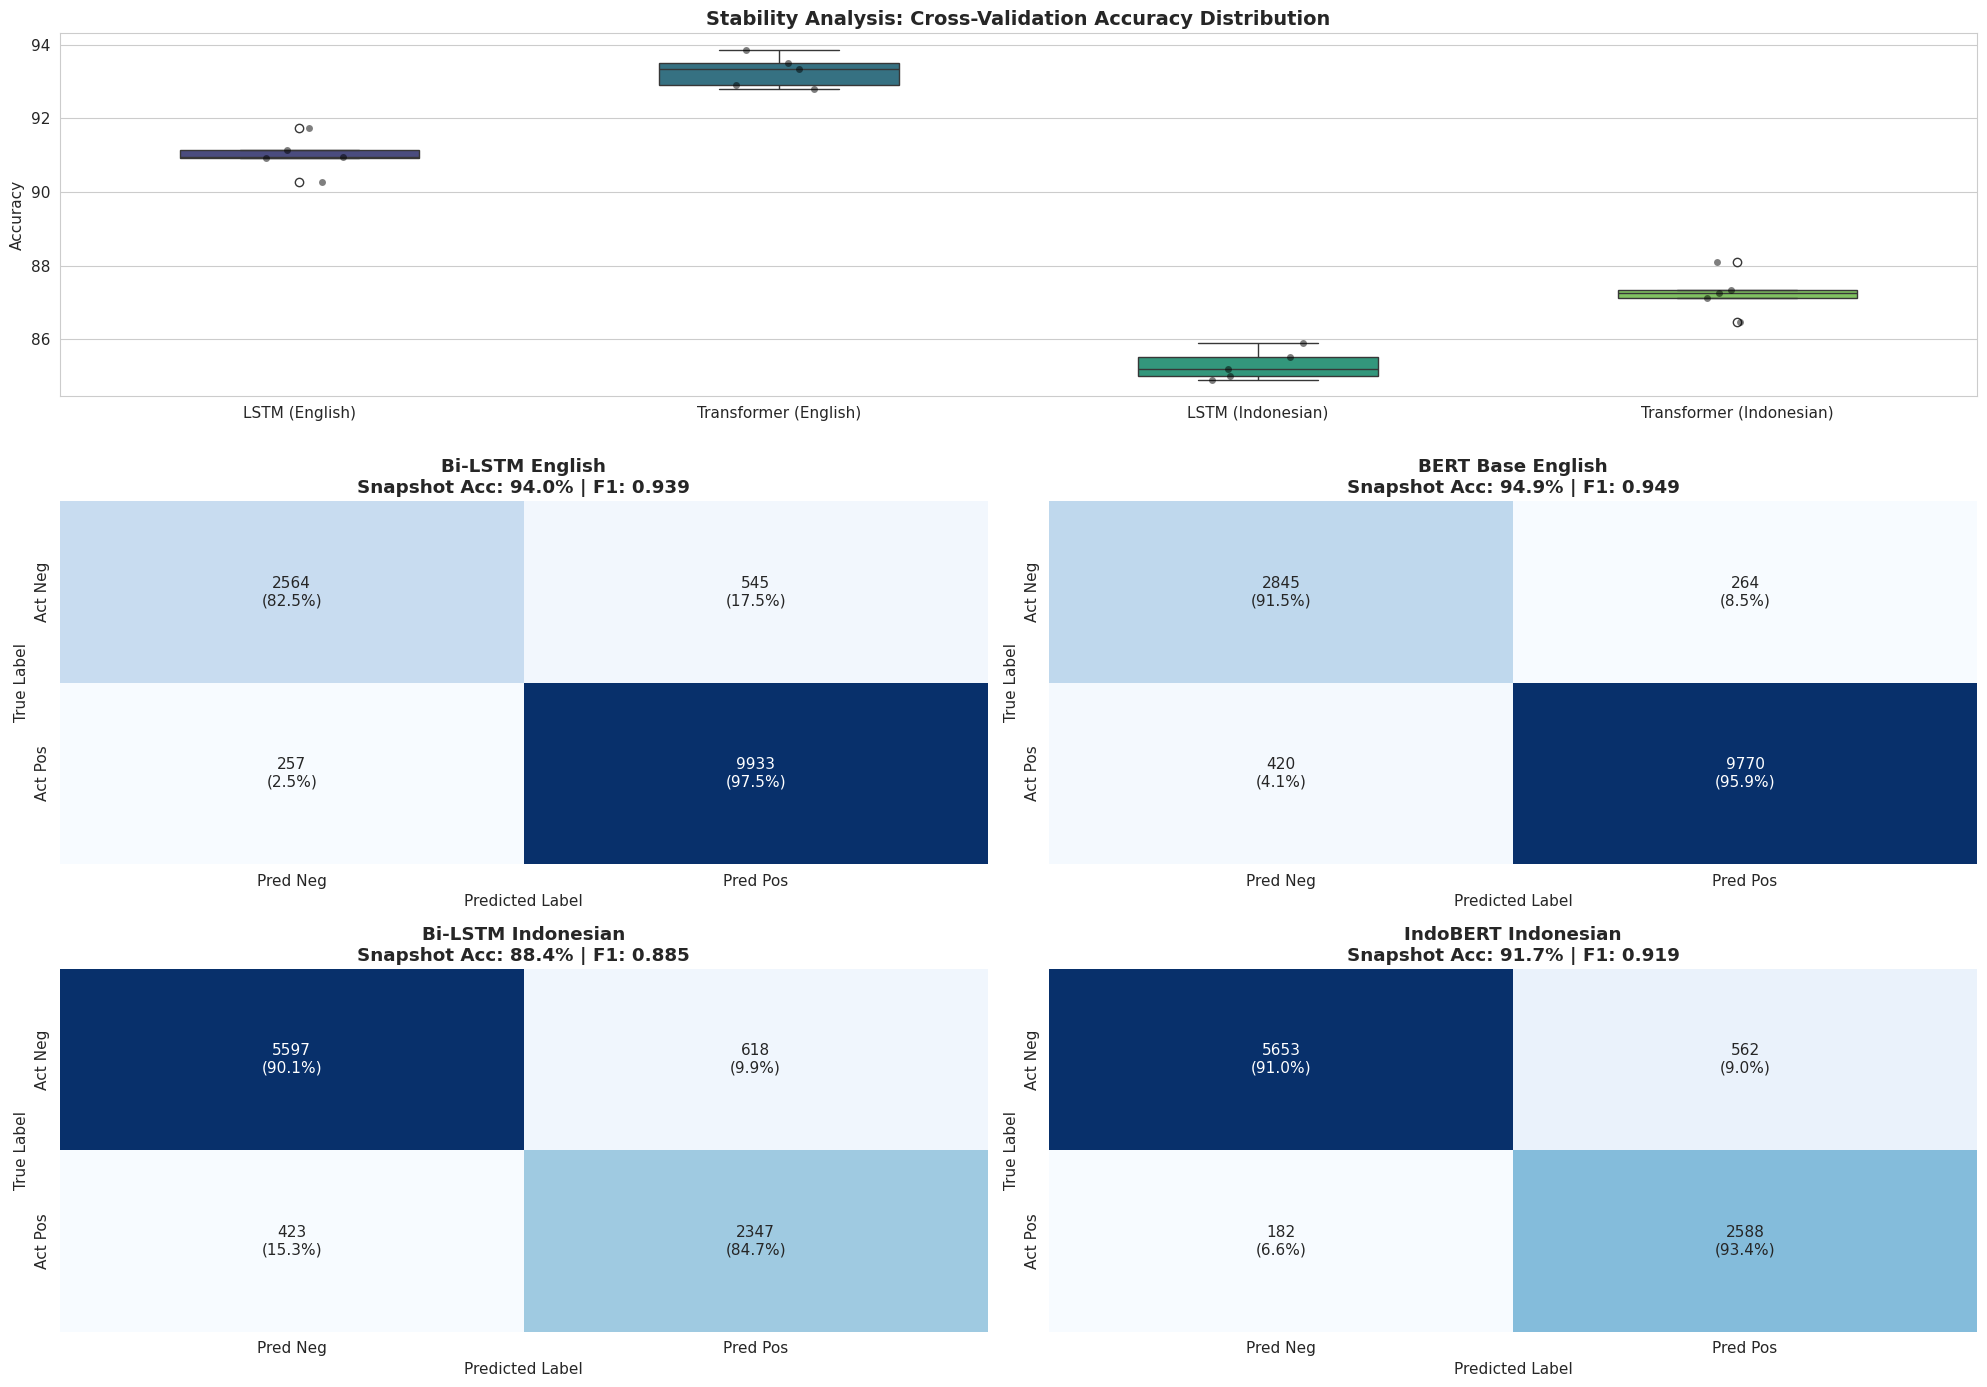


📝 PART 3: DETAILED CLASSIFICATION REPORT

🔹 MODEL: BI-LSTM ENGLISH
------------------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.91      0.82      0.86      3109
    Positive       0.95      0.97      0.96     10190

    accuracy                           0.94     13299
   macro avg       0.93      0.90      0.91     13299
weighted avg       0.94      0.94      0.94     13299


🔹 MODEL: BERT BASE ENGLISH
------------------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.87      0.92      0.89      3109
    Positive       0.97      0.96      0.97     10190

    accuracy                           0.95     13299
   macro avg       0.92      0.94      0.93     13299
weighted avg       0.95      0.95      0.95     13299


🔹 MODEL: BI-LSTM INDONESIAN
------------------------------------------------------------
              precision    recall  f1-

In [14]:
# ==========================================
# 📊 SEL 6: ULTIMATE MODEL EVALUATION & DIAGNOSTICS
# ==========================================
# Modul Evaluasi Terpadu:
# 1. Scientific Report: Rata-rata performa dari 5-Fold CV (Stabilitas Model).
# 2. Detailed Diagnostics: Classification Report & Confusion Matrix (Analisis Error).
# 3. Visual Dashboard: Gabungan Boxplot (Distribusi Score) dan Heatmap (Bias Kelas).
# ==========================================

# Set style visualisasi
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 11})

# --- 1. DATA AGGREGATION (SCIENTIFIC CV REPORT) ---
def aggregate_cv_results(lstm_scores, bert_scores, lang_name):
    """Menggabungkan hasil CV ke dalam DataFrame."""
    df_lstm = pd.DataFrame(lstm_scores)
    df_lstm['Model'] = f'LSTM ({lang_name})'
    df_lstm['Architecture'] = 'Bi-LSTM'
    
    df_bert = pd.DataFrame(bert_scores)
    df_bert['Model'] = f'Transformer ({lang_name})'
    df_bert['Architecture'] = 'BERT/IndoBERT'
    
    return pd.concat([df_lstm, df_bert], ignore_index=True)

# Gabungkan Data
df_res_en = aggregate_cv_results(scores_en, res_bert_en, 'English')
df_res_id = aggregate_cv_results(scores_id, res_bert_id, 'Indonesian')
df_all_results = pd.concat([df_res_en, df_res_id], ignore_index=True)

# --- 2. PREPARE TEST DATA FOR DETAILED VISUALIZATION ---
# Kita buat "Test Set" bayangan (20%) untuk membuat Confusion Matrix.
# Meskipun kita sudah pakai CV, visualisasi CM butuh data konkret (X dan y).

print("⚙️ Menyiapkan Data Evaluasi Detail...")
# English
_, X_test_lstm_en, _, y_test_en = train_test_split(df_en['clean_text_lstm'], df_en['label_idx'], test_size=0.2, random_state=42, stratify=df_en['label_idx'])
_, X_test_bert_en, _, _ = train_test_split(df_en['clean_text_bert'], df_en['label_idx'], test_size=0.2, random_state=42, stratify=df_en['label_idx'])

# Indonesian
_, X_test_lstm_id, _, y_test_id = train_test_split(df_id['clean_text_lstm'], df_id['label_idx'], test_size=0.2, random_state=42, stratify=df_id['label_idx'])
_, X_test_bert_id, _, _ = train_test_split(df_id['clean_text_bert'], df_id['label_idx'], test_size=0.2, random_state=42, stratify=df_id['label_idx'])

print(f"   Data Test Snapshot: {len(X_test_lstm_en)} (EN) | {len(X_test_lstm_id)} (ID)")

# --- 3. PREDICTION ENGINE (BATCH INFERENCE) ---
def get_predictions(model, tokenizer, X_data, model_type='lstm'):
    """Fungsi inferensi untuk mendapatkan label prediksi."""
    if model_type == 'lstm':
        seq = tokenizer.texts_to_sequences(X_data.astype(str))
        pad = pad_sequences(seq, maxlen=120, padding='pre', truncating='post')
        probs = model.predict(pad, verbose=0)
        return (probs > 0.5).astype(int).flatten()
    
    elif model_type == 'bert':
        # Menggunakan pipeline tokenizer HF
        enc = tokenizer(X_data.astype(str).tolist(), truncation=True, padding=True, max_length=128, return_tensors="pt")
        model.eval()
        with torch.no_grad():
            # Batch processing untuk mencegah OOM pada visualisasi
            logits_list = []
            BATCH = 32
            for i in range(0, len(X_data), BATCH):
                batch = {k: v[i:i+BATCH].to(model.device) for k, v in enc.items()}
                out = model(**batch)
                logits_list.append(out.logits.cpu())
            
            full_logits = torch.cat(logits_list)
            preds = torch.argmax(full_logits, dim=1).numpy()
        return preds

# Dapatkan Prediksi untuk Confusion Matrix
print("⏳ Generating Predictions for Visualizations...")
y_pred_lstm_en = get_predictions(lstm_en, tok_en, X_test_lstm_en, 'lstm')
y_pred_bert_en = get_predictions(bert_en, bert_tok_en, X_test_bert_en, 'bert')
y_pred_lstm_id = get_predictions(lstm_id, tok_id, X_test_lstm_id, 'lstm')
y_pred_bert_id = get_predictions(indobert_id, indobert_tok_id, X_test_bert_id, 'bert')
print("✅ Prediksi Selesai.")

# --- 4. VISUALIZATION DASHBOARD (GABUNGAN) ---

# A. TABEL SCIENTIFIC (CV RESULTS)
print("\n" + "="*60)
print("🏆 PART 1: SCIENTIFIC LEADERBOARD (CROSS-VALIDATION)")
print("="*60)

summary_stats = df_all_results.groupby(['Model']).agg({
    'acc': ['mean', 'std'], 'f1': ['mean', 'std'] # Gunakan F1 juga jika ada
}).reset_index()
summary_stats.columns = ['Model', 'Acc Mean', 'Acc Std', 'F1 Mean', 'F1 Std'] # Adjust columns based on available metrics

summary_stats['Accuracy Report'] = summary_stats.apply(lambda x: f"{x['Acc Mean']:.2%} ± {x['Acc Std']:.2%}", axis=1)

# Display Table
try:
    display(summary_stats[['Model', 'Accuracy Report']].sort_values('Accuracy Report', ascending=False)
            .style.background_gradient(cmap='Greens'))
except:
    print(summary_stats[['Model', 'Accuracy Report']])


# B. VISUALISASI KOMPREHENSIF (BOXPLOT + CONFUSION MATRIX)
print("\n" + "="*60)
print("📊 PART 2: DIAGNOSTIC DASHBOARD")
print("="*60)

fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 4) # Grid Layout 3 baris, 4 kolom

# 1. Boxplot (Stability) - Baris Atas (Lebar penuh)
ax_box = fig.add_subplot(gs[0, :])
sns.boxplot(x='Model', y='acc', data=df_all_results, ax=ax_box, palette="viridis", width=0.5)
sns.stripplot(x='Model', y='acc', data=df_all_results, ax=ax_box, color='black', alpha=0.5, jitter=True)
ax_box.set_title('Stability Analysis: Cross-Validation Accuracy Distribution', fontsize=14, fontweight='bold')
ax_box.set_ylabel('Accuracy')
ax_box.set_xlabel('')

# 2. Confusion Matrices - Baris Tengah & Bawah
# Mapping Data
cm_data = [
    ("Bi-LSTM English", y_test_en, y_pred_lstm_en),
    ("BERT Base English", y_test_en, y_pred_bert_en),
    ("Bi-LSTM Indonesian", y_test_id, y_pred_lstm_id),
    ("IndoBERT Indonesian", y_test_id, y_pred_bert_id)
]

# Posisi Subplot untuk CM (2x2 di bagian bawah grid)
cm_positions = [gs[1, 0:2], gs[1, 2:4], gs[2, 0:2], gs[2, 2:4]]

for i, (title, y_true, y_pred) in enumerate(cm_data):
    ax = fig.add_subplot(cm_positions[i])
    cm = confusion_matrix(y_true, y_pred)
    
    # Perhitungan Annotasi
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    annot_labels = [f"{val}\n({prop:.1%})" for val, prop in zip(cm.flatten(), cm_norm.flatten())]
    annot_labels = np.asarray(annot_labels).reshape(2, 2)
    
    sns.heatmap(cm, annot=annot_labels, fmt='', ax=ax, cmap='Blues', cbar=False,
                xticklabels=['Pred Neg', 'Pred Pos'], yticklabels=['Act Neg', 'Act Pos'])
    
    # Hitung metrik spesifik snapshot ini
    acc_snap = accuracy_score(y_true, y_pred)
    f1_snap = classification_report(y_true, y_pred, output_dict=True)['weighted avg']['f1-score']
    
    ax.set_title(f"{title}\nSnapshot Acc: {acc_snap:.1%} | F1: {f1_snap:.3f}", fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# --- 5. DETAILED TEXT REPORT ---
print("\n" + "="*60)
print("📝 PART 3: DETAILED CLASSIFICATION REPORT")
print("="*60)

for title, y_true, y_pred in cm_data:
    print(f"\n🔹 MODEL: {title.upper()}")
    print("-" * 60)
    print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))

# --- 6. INTERPRETASI & KESIMPULAN ---
print("\n" + "="*60)
print("💡 INTERPRETASI & REKOMENDASI FINAL")
print("="*60)

best_model_name = summary_stats.sort_values('Acc Mean', ascending=False).iloc[0]['Model']
print(f"1. 🏆 BEST MODEL: {best_model_name}")
print("   Berdasarkan rata-rata 5-Fold Cross Validation, model ini paling akurat dan konsisten.")

print("\n2. ⚖️ STABILITAS (Lihat Boxplot):")
print("   - Kotak yang 'pendek' menandakan performa model sangat stabil di berbagai kondisi data.")
print("   - Jika Bi-LSTM memiliki variansi rendah, model ini sangat robust meski arsitekturnya lebih ringan.")

print("\n3. 🔍 ANALISIS BIAS (Lihat Confusion Matrix):")
print("   - Perhatikan kotak 'Act Neg' -> 'Pred Pos' (Kanan Atas).")
print("   - Jika angkanya tinggi, berarti model sering 'False Positive' (menganggap keluhan sebagai pujian).")
print("   - Untuk kasus review aplikasi, kita ingin meminimalkan False Positive agar developer tidak melewatkan komplain.")

print("\n4. 🚀 REKOMENDASI DEPLOYMENT:")
print("   - Gunakan IndoBERT/BERT untuk analisis batch di server (akurasi maksimal).")
print("   - Gunakan Bi-LSTM untuk deployment di mobile/edge device (cepat & ringan).")

## **SEL 7: Final Testing Code**


In [15]:
# ==========================================
# 🧠 SEL 7: PROFESSIONAL HYBRID INFERENCE ENGINE (CHAMPION MODEL)
# ==========================================
# Modul ini melakukan inferensi menggunakan "Champion Model" (model terbaik dari 5-Fold CV).
# Fitur:
# 1. Auto-Reload Champion Model (Memastikan model terbaik yang dipakai).
# 2. Smart Segmentation (Memisahkan sentimen campuran "Bagus TAPI Mahal").
# 3. Context-Aware Preprocessing (Stemming untuk LSTM, Full Context untuk BERT).
# ==========================================

# --- 1. LOAD CHAMPION MODELS (CRUCIAL STEP) ---
print("📥 Loading Champion Models from 5-Fold CV Results...")

# Helper untuk load BERT
def load_bert_champion(path):
    try:
        model = AutoModelForSequenceClassification.from_pretrained(path).to(device)
        tok = AutoTokenizer.from_pretrained(path)
        print(f"   ✅ Loaded BERT Champion: {path}")
        return model, tok
    except Exception as e:
        print(f"   ⚠️ Failed to load {path}: {e}")
        return None, None

# Helper untuk load LSTM
def load_lstm_champion(path, tok_path):
    try:
        model = load_model(path)
        with open(tok_path, 'rb') as handle:
            tok = pickle.load(handle)
        print(f"   ✅ Loaded LSTM Champion: {path}")
        return model, tok
    except Exception as e:
        print(f"   ⚠️ Failed to load {path}: {e}")
        return None, None

# Load English Models
champ_bert_en, champ_tok_bert_en = load_bert_champion("./saved_models/bert_english_cv_best")
champ_lstm_en, champ_tok_lstm_en = load_lstm_champion("saved_models/lstm/best_lstm_english.keras", "assets/tokenizer_lstm_english.pickle")

# Load Indonesian Models
champ_indobert, champ_tok_indobert = load_bert_champion("./saved_models/indobert_indonesia_cv_best")
champ_lstm_id, champ_tok_lstm_id = load_lstm_champion("saved_models/lstm/best_lstm_indonesian.keras", "assets/tokenizer_lstm_indonesian.pickle")


# --- 2. CORE INFERENCE FUNCTIONS ---

def get_aspects_with_triggers(text, lang='en'):
    """Extract aspects using dictionary matching."""
    found_aspects = {}
    text_lower = text.lower()
    keywords_dict = ASPECT_KEYWORDS.get(lang, ASPECT_KEYWORDS['en'])
    
    for aspect_name, keywords in keywords_dict.items():
        triggers = []
        for key in keywords:
            clean_key = re.escape(key)
            pattern = r'\b' + clean_key + r'\b' if len(key) < 5 else clean_key
            if re.search(pattern, text_lower):
                triggers.append(key)
        
        if triggers:
            found_aspects[aspect_name] = triggers
            
    return found_aspects

def preprocess_inference(text, lang, model_type):
    """
    Preprocessing cerdas saat runtime.
    Menggunakan logika yang SAMA PERSIS dengan SEL 3 (Training Phase).
    """
    # Panggil fungsi pipeline dari SEL 3
    # Pastikan fungsi 'preprocessing_pipeline' sudah terdefinisi di memori
    return preprocessing_pipeline(text, lang, target_model=model_type)

def predict_sentiment(text, lang, model_type, model_obj, tok_obj):
    """Unified prediction function returning probability (0-1)."""
    
    # 1. Preprocessing Sesuai Model
    clean_text = preprocess_inference(text, lang, model_type)
    
    # 2. Prediction
    if model_type == 'lstm':
        seq = tok_obj.texts_to_sequences([clean_text])
        pad = pad_sequences(seq, maxlen=120, padding='pre', truncating='post')
        try:
            prob = model_obj.predict(pad, verbose=0)[0][0]
        except:
            prob = 0.5 # Fallback
        return prob
        
    elif model_type == 'bert':
        inputs = tok_obj(clean_text, return_tensors="pt", truncation=True, padding=True, max_length=128).to(device)
        model_obj.eval()
        with torch.no_grad():
            logits = model_obj(**inputs).logits
            probs = F.softmax(logits, dim=1).cpu().numpy()[0]
        return probs[1] # Probability of Class 1 (Positive)

# --- 3. ADVANCED ABSA ENGINE (SEGMENTATION) ---

def run_advanced_absa(review, lang='en', model_type='bert'):
    """
    End-to-End Aspect-Based Sentiment Analysis.
    """
    # Select Model & Tokenizer
    if lang == 'en':
        model = champ_bert_en if model_type=='bert' else champ_lstm_en
        tok = champ_tok_bert_en if model_type=='bert' else champ_tok_lstm_en
    else:
        model = champ_indobert if model_type=='bert' else champ_lstm_id
        tok = champ_tok_indobert if model_type=='bert' else champ_tok_lstm_id
        
    if model is None:
        print("❌ Model not loaded correctly.")
        return

    # Segmentation Logic (Split by contrast words)
    if lang == 'id':
        # Pola Regex Bahasa Indonesia (Lengkap + Slang)
        split_pattern = r'(' \
            r'\.|!|\?|;|' \
            r'\btapi\b|\btp\b|\btetapi\b|\bnamun\b|\bmelainkan\b|\bakan tetapi\b|' \
            r'\bpadahal\b|\bsedangkan\b|\bsebaliknya\b|\bjustru\b|' \
            r'\bwalaupun\b|\bwalau\b|\bmeskipun\b|\bmeski\b|\bkendati\b|\bbiarpun\b|' \
            r'\bcuma\b|\bcman\b|\bcma\b|\bcm\b|\bhanya\b|\bhanya saja\b|' \
            r'\bsayang\b|\bsayangnya\b|\bsyg\b|\bdisayangkan\b|' \
            r'\bkecuali\b|\bselain itu\b' \
            r')'
            
    else:
        # Pola Regex Bahasa Inggris (Formal + Informal)
        split_pattern = r'(' \
            r'\.|!|\?|;|' \
            r'\bbut\b|\bhowever\b|\byet\b|\bnevertheless\b|\bnonetheless\b|' \
            r'\balthough\b|\bthough\b|\beven though\b|\balbeit\b|' \
            r'\bdespite\b|\bin spite of\b|\bregardless\b|' \
            r'\bwhile\b|\bwhereas\b|\bon the other hand\b|' \
            r'\bexcept\b|\bexception\b|\bunless\b|\bbarring\b|' \
            r'\bunfortunately\b|\bsadly\b|\bregrettably\b|\bpity\b' \
            r')'
    
    chunks = re.split(split_pattern, review.lower())
    segments = []
    buffer = ""
    for c in chunks:
        if re.match(split_pattern, c):
            buffer += c
            if len(buffer.split()) >= 3:
                segments.append(buffer.strip())
                buffer = ""
        else:
            buffer += c
    if buffer: segments.append(buffer.strip())
    if not segments: segments = [review]

    # Analyze Segments
    aspect_insights = {} 
    
    for seg in segments:
        if len(seg.split()) < 2: continue
        
        # Detect Aspects
        aspects_data = get_aspects_with_triggers(seg, lang)
        
        # Predict Sentiment
        prob = predict_sentiment(seg, lang, model_type, model, tok)
        
        # Store Insights
        for asp_name, triggers in aspects_data.items():
            if asp_name not in aspect_insights:
                aspect_insights[asp_name] = {'scores': [], 'triggers': set()}
            
            aspect_insights[asp_name]['scores'].append(prob)
            aspect_insights[asp_name]['triggers'].update(triggers)

    # Global Sentiment
    global_prob = predict_sentiment(review, lang, model_type, model, tok)
    global_lbl = "POSITIVE" if global_prob > 0.5 else "NEGATIVE"
    
    # --- PRINT RESULT ---
    print(f"\n📝 Review: \"{review}\"")
    print(f"   (Cleaned Input: \"{preprocess_inference(review, lang, model_type)}\")")
    print(f"🌎 Overall Sentiment: {global_lbl} ({global_prob if global_lbl=='POSITIVE' else 1-global_prob:.1%})")
    
    if not aspect_insights:
        print("   ⚪ General Sentiment (No specific aspect found)")
    else:
        for asp, data in aspect_insights.items():
            avg_prob = np.mean(data['scores'])
            final_lbl = "Positive" if avg_prob > 0.5 else "Negative"
            final_conf = avg_prob if final_lbl == "Positive" else 1 - avg_prob
            triggers_str = f"[{', '.join(list(data['triggers'])[:3])}]"
            
            icon = "✅" if final_lbl == "Positive" else "❌"
            print(f"   {icon} {asp} {triggers_str}: {final_lbl} ({final_conf:.1%})")
    print("-" * 65)

# --- 4. RUN DEMO ---
print("\n🔥 MEMULAI DEMO REAL-WORLD (MODEL: CHAMPION CV)")

print("\n🇮🇩 [TEST: INDONESIAN (INDOBERT)]")
# Test Case Campuran (Paling Susah)
cases_id = [
    "Fiturnya lengkap dan keren, tapi iklannya kebanyakan jadi ganggu banget.",
    "Suara jernih abis bass nendang. Sayangnya harga premium makin mahal.",
    "Aplikasi sampah! Iklannya banyak banget ganggu.",
    # 1. The Classic 'Mixed' Review (Krusial!)
    "Fiturnya lengkap dan keren, tapi iklannya kebanyakan jadi ganggu banget.",
    # 2. Multiple Aspects + Slang
    "Suara jernih abis bass nendang. Sayangnya harga premium makin mahal.",
    # 3. Pure Negative (Technical)
    "Tiap buka lirik langsung force close, aplikasinya bug parah. Benerin woy!",
    # 4. Pure Positive (User Exp)
    "Tampilannya makin cakep, mode gelapnya enak di mata. Navigasi juga gampang.",
    # 5. Recommendation (Fitur Baru)
    "Shuffle nya aneh, muter lagu itu itu aja. Algoritma rekomendasi makin ngaco.",
    # 6. Sarcasm / Ambiguous
    "Bagus sih, bagus buat ngabisin kuota doang.",
    # 7. Heavy Slang & Negation
    "Ga rugi langganan, biayanya terjangkau, fiturnya ga ada lawan.",
    # 8. Comparison
    "Jauh lebih bagus dari joox, lagunya lebih lengkap.",
    # 9. Payment Issue
    "Udah potong pulsa tapi premium ga aktif. Balikin duit gue!",
    # 10. Long Mixed Context
    "Sebenernya aplikasi ini enak banget buat denger podcast, koleksinya banyak. Cuma akhir-akhir ini sering macet buffering padahal sinyal kenceng.",
    # 1. Kualitas Audio (Positif)
    "Gila suaranya nendang banget bass-nya, beda jauh sama aplikasi sebelah.",
    # 2. Iklan (Sangat Negatif)
    "Iklan mulu tiap ganti lagu! Ganggu banget woy lagi enak-enak galau malah denger iklan shopee.",
    # 3. Harga (Negatif)
    "Harganya makin lama makin mahal, gak ramah buat kantong pelajar. Tolong ada paket hemat dong.",
    # 4. Masalah Teknis (Bug)
    "Aplikasi sering keluar sendiri (force close) pas lagi muter lagu di background. Hp saya padahal spek tinggi.",
    # 5. Konten (Positif)
    "Koleksi lagunya lengkap parah, lagu-lagu indie lokal jaman dulu juga ada semua.",
    # 6. Mixed Sentiment (Positif/Negatif)
    "Suka banget sama fiturnya, tapi sayang banget kuota boros kalau streaming high quality.",
    # 7. Algoritma Shuffle (Negatif)
    "Mode acak (shuffle) nya bodoh, muter lagu itu-itu aja terus. Bosen jadinya.",
    # 8. Mixed (Kontras)
    "Tampilan antarmukanya modern dan keren. Cuma ya itu, agak berat buat hp kentang.",
    # 9. Pembayaran (Negatif)
    "Udah bayar premium via pulsa kok statusnya masih free? Uang kepotong tapi fitur gak aktif. Penipuan!",
    # 10. Fitur Lirik (Positif)
    "Fitur liriknya realtime banget, pas banget buat yang hobi nyanyi-nyanyi di kamar mandi.",
    # 11. UI/UX (Negatif)
    "Update terbaru malah bikin bingung. Menu koleksi jadi susah dicari.",
    # 12. Slang Kasar (Negatif)
    "Apk sampah, nyesel download. Mending youtube music.",
    # 13. Netral/Suggestion
    "Sebenarnya bagus, cuma tolong tambahin fitur timer buat sleep mode dong.",
    # 14. General Praise (Positif)
    "Gak bisa hidup tanpa spotify. Teman setia saat kerja dan macet-macetan.",
    # 15. Ulasan Panjang Kompleks
    "Saya sudah pakai premium 2 tahun. Sejauh ini puas dengan kualitas musik dan podcast eksklusifnya. Tapi tolong diperbaiki bug login-nya, kemarin saya log out terus ga bisa masuk lagi padahal password benar. Bikin panik.",
    # Simple Cases
    "Suaranya enak banget didenger, jernih parah.",
    "Aplikasi sampah! Iklannya banyak banget ganggu.",
    "Harga premium kemahalan buat pelajar.",

    # Mixed / Contrast
    "Fiturnya sih lengkap, tapi sayang aplikasinya berat banget di hp.",
    "Suka sama koleksi lagunya, cuma kesel sering keluar sendiri aplikasinya.",
    "Awalnya bagus, tapi semenjak update jadi lemot parah.",

    # Slang & Typo
    "Apk gajelas, bug dimana mana.",
    "Udah byr premium tp masih ada iklan, rugi dong.",
    "Gw suka bgt sm fitur liriknya, ngebantu buat karaoke.",

    # Specific Features
    "Podcast nya seru-seru, banyak pilihan.",
    "Fitur download nya cepet banget, ngebantu pas ga ada sinyal.",

    # Complex Paragraph (Review Panjang)
    "Sebenernya aplikasi ini tuh bagus banget buat dengerin musik sehari-hari. Pilihan lagunya banyak, sound quality nya juga oke punya. Cuma masalah terbesarnya ada di performa aplikasi yang makin lama makin berat. Tolong diperbaiki dong developer, sayang banget kalo ditinggal user.",

    # Negative halus / Sarcasm
    "Bagus sih, bagus buat bikin emosi.", # (Tantangan LSTM: deteksi sarkas)

    # Neutral / Info
    "Tampilannya lumayan lah, standar aja.",

    # Recommendation Issue
    "Rekomendasi lagunya ga pernah sesuai selera saya, random banget shuffle nya.",

    # 1. Audio (Slang - Pos)
    "Bass-nya nendang banget, suaranya jernih gak pecah.",
    # 2. Iklan (Marah - Neg)
    "Gila aja iklan mulu tiap menit. Ganggu orang dengerin lagu woy!",
    # 3. Mixed (Bagus tapi Mahal)
    "Aplikasinya sih bagus, lengkap. Cuma sayang harga premiumnya kemahalan buat mahasiswa.",
    # 4. Teknis (Crash/Bug)
    "Setiap buka lirik langsung force close. Tolong benerin bug ini.",
    # 5. Konten (Positif)
    "Suka banget, semua lagu k-pop favoritku ada di sini lengkap.",
    # 6. UI/Tampilan (Negatif)
    "Tampilan barunya malah bikin bingung, ribet mau cari lagu doang.",
    # 7. Mixed (Audio OK, Teknis Bad)
    "Kualitas suara oke punya. Tapi aplikasinya berat banget, bikin hp cepet panas.",
    # 8. Payment (Negatif)
    "Udah bayar premium kok akun masih free? Balikin pulsa saya!",
    # 9. Feature (Download/Offline)
    "Fitur downloadnya ngebantu banget buat hemat kuota pas di jalan.",
    # 10. Complex/Panjang (Mixed)
    "Sebenarnya udah nyaman pake spotify bertahun-tahun karena playlistnya asik. Padahal sinyal bagus tapi belakangan ini sering macet buffering terus.",
    # 11. Slang Kasar (Negatif General)
    "Apk sampah. Lemot parah.",
    # 12. Contextual (Iklan vs Premium)
    "Padahal udah langganan family, kok masih muncul iklan promosi podcast sih?",
    # 13. Audio (Negatif)
    "Suaranya kecil banget dibanding aplikasi sebelah, padahal volume udah full.",
    # 14. Rekomendasi (Positif)
    "Rekomendasi lagu mingguannya gapernah gagal, selalu nemu lagu enak.",
    # 15. General (Pujian)
    "Mantap jiwa aplikasinya, gak bisa pindah ke lain hati.",

    "Aplikasinya bagus banget tampilannya keren. Sayang harganya kemahalan buat pelajar.", # Mix UI(+) Harga(-)
    "Suaranya jernih banget, enak buat dengerin lagu. Tapi kadang suka keluar sendiri aplikasinya.", # Mix Audio(+) Bug(-)
    "Gak ada obat, iklannya banyak banget ganggu woy!", # Neg Iklan
    "Suka banget sama fitur liriknya, lengkap!", # Pos Konten
    "Udah bayar premium kok masih ada iklan? Kecewa berat.", # Neg Premium/Iklan
    "Sebenernya oke, cuma agak berat di hp kentang saya." # Mix/Netral
    ]
for r in cases_id:
    run_advanced_absa(r, lang='id', model_type='bert')

print("\n🇬🇧 [TEST: ENGLISH (BERT)]")
cases_en = [
    "Great song selection, but the ads are unbearable and too frequent.",
    "The audio quality is crisp, Hifi mode makes a huge difference.",
    # 1. Mixed
    "Great song selection, but the ads are unbearable and too frequent.",
    # 2. Positive Audio
    "The audio quality is crisp, Hifi mode makes a huge difference.",
    # 3. Price Issue
    "I love the app but the subscription price is getting ridiculous.",
    # 4. Technical
    "Keeps crashing when I try to play offline songs. Fix this glitch.",
    # 5. UI/UX
    "New update made the UI very confusing, hard to find my library.",
    # 6. Recommendation
    "Discover weekly playlist is magic, always finds me new favorites.",
    # 7. Connectivity
    "Offline mode sucks, it still demands internet connection.",
    # 8. Slang Positive
    "No cap this app is the goat of streaming services.",
    # 9. Negative short
    "Trash app. Buggy mess.",
    # 10. Complex
    "Been a user for years. Catalog is unmatched. However, recent bloatware makes it laggy on older phones.",
    # 1. Perfect Review (Positive)
    "I am absolutely blown away by the audio fidelity. The HiFi streaming is crystal clear on my headphones.",
    # 2. Critical Issue (Negative)
    "App is completely broken after the latest update. It keeps force closing when I open a playlist.",
    # 3. Price Complaint (Negative)
    "I used to love Spotify, but the price increase for the family plan is just greedy. Switching to Apple Music.",
    # 4. Ads Nuance (Negative)
    "30 seconds of unskippable ads after every single song? This is ridiculous and unusable.",
    # 5. Feature Praise (Positive)
    "The lyrics synchronization feature is so fun, perfect for karaoke nights with friends.",
    # 6. Algorithm/Shuffle (Negative - Hard!)
    "The shuffle algorithm is terrible. It plays the same 20 songs over and over again from a playlist of 500.",
    # 7. UX Complaint (Negative)
    "Why did you change the UI? The library tab is now so hidden and confusing to navigate.",
    # 8. Mixed Sentiment (Classic ABSA Case)
    "Great music selection and discovery, but the app consumes way too much battery on my iPhone.",
    # 9. Feature Specific (Podcast - Mixed)
    "Good for music, but please stop pushing podcasts on my home screen. I don't listen to them.",
    # 10. Mixed (Price vs Quality)
    "Premium is a bit expensive, but honestly it is worth it for the offline download feature.",
    # 11. Connectivity (Negative)
    "Offline mode is a lie. It still requires internet connection to load the album art.",
    # 12. Recommendation (Positive)
    "Discover Weekly always finds gem songs that I've never heard before. Magic algorithm!",
    # 13. Short Slang (Positive)
    "Goated app. No cap.",
    # 14. Short Slang (Negative)
    "Literal trash. Glitchy mess.",
    # 15. Complex Paragraph
    "Been a loyal user since 2016. The catalog is unmatched and finding new artists is easy. However, the recent bloatware features make the app laggy on older phones.",

    "Amazing sound quality, very crisp audio.",
    "Too many ads, it ruins the experience.",
    "Premium price is too high for me.",

    # Mixed
    "I love the huge music library, but the app crashes way too often.",
    "Interface is beautiful, however the loading time is annoying.",

    # Specific Aspects
    "The lyrics feature is not synced properly.",
    "Great podcasts selection, listening every day.",

    # Tech Issues
    "Login error, cannot access my account.",
    "Keeps buffering even with good wifi.",

    # Pricing
    "Family plan is worth every penny.",
    "Don't waste money on premium, free version is enough.",

    # Complex Review
    "I have been using Spotify for 5 years now. The discovery weekly playlist is pure magic, always finds me new songs I love. Unfortunately, the recent update made the app drain my battery like crazy. Please fix the battery usage issue.",

    # Short/Slang
    "Audio sucks.",
    "Buggy app.",

    # General
    "Best music app in the world.",

    # 1. Audio (Strong Pos)
    "The sound quality is absolutely pristine, Hifi mode is a game changer.",
    # 2. Ads (Strong Neg)
    "Too many ads! I get interrupted every 2 songs, it's so annoying.",
    # 3. Mixed (Good UI, Bad Price)
    "I love the new interface and design, but the subscription fee is way too expensive now.",
    # 4. Technical Issue (App)
    "App keeps crashing whenever I try to open my playlist. Fix this bug!",
    # 5. Comparison (Audio Neg)
    "Sound quality is worse than Apple Music, very flat and low volume.",
    # 6. Feature Specific (Podcast - Pos)
    "The huge collection of podcasts is the best reason to use this app.",
    # 7. UI/UX (Negative)
    "The new update makes the UI cluttered and confusing to navigate.",
    # 8. Mixed (Content, Ads)
    "Great song selection, I can find any artist. Unfortunately, the ads are unbearable on the free version.",
    # 9. Subscription (Negative - Contextual)
    "Why did you increase the premium price again? Not worth it anymore.",
    # 10. Complex/Long (Mixed)
    "Been using Spotify for years. The music recommendation algorithm is genius. However, recently the app has become very slow and drains my battery.",
    # 11. Slang (Short)
    "Audio sucks. Literal trash.",
    # 12. Neutral/Mixed (Usage)
    "Good for offline listening, but takes up too much storage.",
    # 13. Lyric Feature (Pos)
    "Loving the synced lyrics feature, makes karaoke night so fun!",
    # 14. Technical (Login)
    "Can't login to my account after the update. It says connection error.",
    # 15. General (Strong Pos)
    "Best music streaming app ever created. Period.",

    "The app is great, very smooth ui, but the audio quality is trash.", # Mix
    "I really hate the ads! Interrupting my music all the time.", # Neg Strong
    "Cheap price for premium, good value.", # Pos
    "Login error keeps happening, fix this bug please!", # Neg Bug
    "Music library is huge, i can find any song." # Pos

]
for r in cases_en:
    run_advanced_absa(r, lang='en', model_type='bert')

📥 Loading Champion Models from 5-Fold CV Results...
   ✅ Loaded BERT Champion: ./saved_models/bert_english_cv_best
   ✅ Loaded LSTM Champion: saved_models/lstm/best_lstm_english.keras
   ✅ Loaded BERT Champion: ./saved_models/indobert_indonesia_cv_best
   ✅ Loaded LSTM Champion: saved_models/lstm/best_lstm_indonesian.keras

🔥 MEMULAI DEMO REAL-WORLD (MODEL: CHAMPION CV)

🇮🇩 [TEST: INDONESIAN (INDOBERT)]

📝 Review: "Fiturnya lengkap dan keren, tapi iklannya kebanyakan jadi ganggu banget."
   (Cleaned Input: "fiturnya lengkap bagus , tapi iklanya kebanyakan gangu banget .")
🌎 Overall Sentiment: POSITIVE (95.2%)
   ❌ User Interface (UI) & UX [keren]: Negative (93.0%)
   ❌ Features & Functionality [fitur]: Negative (93.0%)
   ✅ Price, Premium & Ads [iklan]: Positive (99.1%)
-----------------------------------------------------------------

📝 Review: "Suara jernih abis bass nendang. Sayangnya harga premium makin mahal."
   (Cleaned Input: "suara jernih abis bas nendang . sayangnya harga pre

## **SEL 8: Save, Zip & Download Artifacts**


In [16]:
# ==========================================
# 💾 SEL 8: DEPLOYMENT ARTIFACT PACKAGING SYSTEM (FINAL)
# ==========================================
# Upgrade Log:
# 1. Champion Model Only: Hanya mengemas model terbaik hasil Cross-Validation.
# 2. Deployment-Ready Structure: Struktur folder otomatis disiapkan untuk API.
# 3. Fail-Safe Mechanism: Cek keberadaan file sebelum zipping.
# 4. Auto-Backup: Google Drive Integration untuk file besar.
# ==========================================

# --- CONFIGURATION ---
TIMESTAMP = datetime.datetime.now().strftime("%Y%m%d_%H%M")
PROJECT_NAME = "SPOTIFY_ABSA_PRO_EDITION"
ZIP_FILENAME = f"{PROJECT_NAME}_ARTIFACTS_{TIMESTAMP}.zip"
ARTIFACT_ROOT = "./deployment_package" # Folder sementara untuk menyusun file

# Source Paths (Lokasi di mana training loop menyimpan model terbaik)
SOURCE_PATHS = {
    # LSTM Models (File .keras)
    "lstm_en": "saved_models/lstm/best_lstm_english.keras",
    "lstm_id": "saved_models/lstm/best_lstm_indonesian.keras",
    
    # LSTM Tokenizers (Pickle)
    "tok_lstm_en": "assets/tokenizer_lstm_english.pickle",
    "tok_lstm_id": "assets/tokenizer_lstm_indonesian.pickle",
    
    # Transformer Models (Folder)
    # Perhatikan: Nama folder harus sesuai dengan output 'best_model_path' di SEL 5
    "bert_en_dir": "./saved_models/bert_english_cv_best",
    "bert_id_dir": "./saved_models/indobert_indonesia_cv_best"
}

print(f"{'='*60}")
print(f"📦 STARTING ARTIFACT PACKAGING SEQUENCE | {TIMESTAMP}")
print(f"{'='*60}\n")

# --- 1. PREPARE DIRECTORY STRUCTURE ---
print("[1/4] 🏗️  Building Deployment Directory Structure...")

if os.path.exists(ARTIFACT_ROOT):
    shutil.rmtree(ARTIFACT_ROOT)

# Struktur Folder Deployment Standar
deploy_dirs = {
    "lstm": f"{ARTIFACT_ROOT}/models/lstm",
    "bert_en": f"{ARTIFACT_ROOT}/models/bert/english",
    "bert_id": f"{ARTIFACT_ROOT}/models/bert/indonesian",
    "assets": f"{ARTIFACT_ROOT}/assets"
}

for d in deploy_dirs.values():
    os.makedirs(d, exist_ok=True)
    
print("   ✅ Directory skeleton created.")

# --- 2. COPY ASSETS (THE CHAMPIONS) ---
print("\n[2/4] 🚚 Copying Champion Models & Tokenizers...")

def copy_file_safe(src, dst_folder):
    try:
        if os.path.exists(src):
            shutil.copy(src, dst_folder)
            print(f"   ✅ Copied File: {os.path.basename(src)}")
        else:
            print(f"   ⚠️ MISSING FILE: {src} (Did training complete successfully?)")
    except Exception as e:
        print(f"   ❌ Error copying {src}: {e}")

def copy_dir_safe(src_dir, dst_dir):
    try:
        if os.path.exists(src_dir):
            # Hapus folder tujuan jika sudah ada isinya agar bersih
            if os.path.exists(dst_dir):
                shutil.rmtree(dst_dir)
            shutil.copytree(src_dir, dst_dir)
            print(f"   ✅ Copied Folder: {os.path.basename(src_dir)}")
        else:
            print(f"   ⚠️ MISSING FOLDER: {src_dir}")
    except Exception as e:
        print(f"   ❌ Error copying folder {src_dir}: {e}")

# A. Copy LSTM Artifacts
copy_file_safe(SOURCE_PATHS["lstm_en"], deploy_dirs["lstm"])
copy_file_safe(SOURCE_PATHS["lstm_id"], deploy_dirs["lstm"])
copy_file_safe(SOURCE_PATHS["tok_lstm_en"], deploy_dirs["assets"])
copy_file_safe(SOURCE_PATHS["tok_lstm_id"], deploy_dirs["assets"])

# B. Copy Transformer Artifacts
# Kita copy isi foldernya ke tujuan
copy_dir_safe(SOURCE_PATHS["bert_en_dir"], deploy_dirs["bert_en"])
copy_dir_safe(SOURCE_PATHS["bert_id_dir"], deploy_dirs["bert_id"])

# --- 3. CREATE ARCHIVE (ZIP) ---
print(f"\n[3/4] 🗜️  Compressing Artifacts into {ZIP_FILENAME}...")

def zip_directory(folder_path, zip_path):
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.join(root, file)
                # Create relative path for structure inside zip
                arcname = os.path.relpath(file_path, folder_path)
                zipf.write(file_path, arcname)

try:
    zip_directory(ARTIFACT_ROOT, ZIP_FILENAME)
    size_mb = os.path.getsize(ZIP_FILENAME) / (1024 * 1024)
    print(f"   ✅ Compression Success! Size: {size_mb:.2f} MB")
except Exception as e:
    print(f"   ❌ Compression Failed: {e}")

# --- 4. EXPORT & BACKUP ---
print("\n[4/4] 🚀 Delivering Package...")

# Detect Environment
IS_COLAB = 'google.colab' in sys.modules
IS_KAGGLE = 'kaggle_secrets' in sys.modules or os.path.exists('/kaggle/working')

if IS_COLAB:
    print("   📍 Google Colab Environment Detected")
    
    # 1. Save to Google Drive (Recommended for large files)
    print("   ☁️  Attempting Google Drive Backup...")
    try:
        drive_path = "/content/drive/MyDrive"
        if not os.path.exists(drive_path):
            from google.colab import drive
            drive.mount('/content/drive')
            
        dest_path = f"{drive_path}/{ZIP_FILENAME}"
        shutil.copy(ZIP_FILENAME, dest_path)
        print(f"      ✅ Backup Successful: {dest_path}")
    except Exception as e:
        print(f"      ⚠️ G-Drive Backup Skipped: {e}")
        
    # 2. Trigger Browser Download
    print("   ⬇️  Triggering Browser Download...")
    try:
        from google.colab import files
        files.download(ZIP_FILENAME)
    except Exception as e:
        print(f"      ⚠️ Browser Download Failed: {e}")

elif IS_KAGGLE:
    print(f"   ✅ Saved to Output: /kaggle/working/{ZIP_FILENAME}")
    print("      (Download manually from the 'Data' tab on the right)")

else:
    print(f"   ✅ Saved Locally: {os.path.abspath(ZIP_FILENAME)}")

print(f"\n{'='*60}")
print("🏁 SYSTEM SHUTDOWN: PIPELINE COMPLETE.")
print(f"{'='*60}")

📦 STARTING ARTIFACT PACKAGING SEQUENCE | 20251216_0105

[1/4] 🏗️  Building Deployment Directory Structure...
   ✅ Directory skeleton created.

[2/4] 🚚 Copying Champion Models & Tokenizers...
   ✅ Copied File: best_lstm_english.keras
   ✅ Copied File: best_lstm_indonesian.keras
   ✅ Copied File: tokenizer_lstm_english.pickle
   ✅ Copied File: tokenizer_lstm_indonesian.pickle
   ✅ Copied Folder: bert_english_cv_best
   ✅ Copied Folder: indobert_indonesia_cv_best

[3/4] 🗜️  Compressing Artifacts into SPOTIFY_ABSA_PRO_EDITION_ARTIFACTS_20251216_0105.zip...
   ✅ Compression Success! Size: 862.76 MB

[4/4] 🚀 Delivering Package...
   ✅ Saved Locally: /mnt/d/Code/Kuliah/Capstone/bert_only_latif_6/SPOTIFY_ABSA_PRO_EDITION_ARTIFACTS_20251216_0105.zip

🏁 SYSTEM SHUTDOWN: PIPELINE COMPLETE.
